# 2b. Heating Oil Meta-Model
### Heating Oil Futures (ho1s)

In this notebook we develop the meta-model for heating oil (ho1s). Meta-labelling uses a secondary model to decide whether to act on a primary model's signal. The primary signal says which way to trade, and the meta-model gives each of those signals a probability of being a genuine opportunity rather than noise.

We start from the assembled feature matrix built in notebook 1, which gives every instrument a common set of base features. On top of that we add a few heating oil specific features, the latent regime features, and the primary-signal features, then reduce everything with PCA, label the trades with the triple-barrier method, and compare a range of models. Every feature is strictly backward looking, so nothing here uses information from the future.

## 1. Imports

We load the standard scientific Python stack together with scikit-learn, XGBoost and Keras. These cover the data handling, the classical models, and the neural networks used later on.

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

# Reproducibility: fix every RNG (NumPy, Python, TensorFlow) to one seed
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 2. Load the Feature Matrix

We load the assembled feature matrix and, for heating oil, add the more specific data on top before running the triple-barrier method and the HMM for the regime state. The base features were built in the feature engineering notebook, and the idea is to keep a common set of base features that we can then enrich, so the meta-model has both general and heating oil specific information to work with.

In [87]:
features = pd.read_parquet('../data/processed/features/features.parquet')
features['date'] = pd.to_datetime(features['date'])
feat_dict = pd.read_csv('../data/processed/features/feature_dictionary.csv')

print('Shape:', features.shape)
print('Date range:', features['date'].min().date(), '→', features['date'].max().date())
print('Instruments:', sorted(features['instrument'].unique()))
print('Feature columns:', len(features.columns) - 3)  # minus date, instrument, primary_signal

Shape: (2512, 63)
Date range: 2020-01-03 → 2022-06-30
Instruments: ['cl1s', 'ho1s', 'ng1s', 'rb1s']
Feature columns: 60


## 3. Tier 1: Base Features

We keep the heating oil rows (ho1s), sort them by date, and recap the Tier 1 base features. These are the general price and volatility features that apply to any instrument, such as returns, momentum, rolling volatility, and the trend-scanning t-statistics. They describe what prices have actually done and form the backbone that the later tiers build on.

In [88]:
heating_oil = features[features['instrument'] == 'ho1s'].set_index('date').sort_index().copy()
print(heating_oil.shape)
heating_oil.head()

(628, 62)


,instrument,primary_signal,ret_1d,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,...,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size,primary_signal_lag1,primary_signal_lag5,primary_signal_streak
date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,ho1s,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,ho1s,0.0,0.018428,0.018260,0.003840,0.020733,0.070145,0.083901,0.009637,0.012989,...,0.997088,0.002912,0.014447,41.0,0.998434,0.0,0.75,NaN,NaN,0.0
2020-01-07,ho1s,0.0,-0.013340,-0.013430,-0.008811,0.002759,0.051476,0.065666,0.010339,0.013120,...,0.997937,0.002063,0.013622,42.0,0.999299,0.0,0.50,0.0,NaN,1.0
2020-01-08,ho1s,0.0,-0.000738,-0.000738,-0.005593,0.005823,0.040905,0.064147,0.010218,0.013123,...,0.998498,0.001502,0.013077,43.0,0.999323,0.0,0.75,0.0,NaN,2.0
2020-01-09,ho1s,0.0,-0.036509,-0.037192,-0.032457,-0.032111,0.007769,0.007978,0.013438,0.013809,...,0.986853,0.013147,0.024386,44.0,0.985763,0.0,1.00,0.0,NaN,3.0


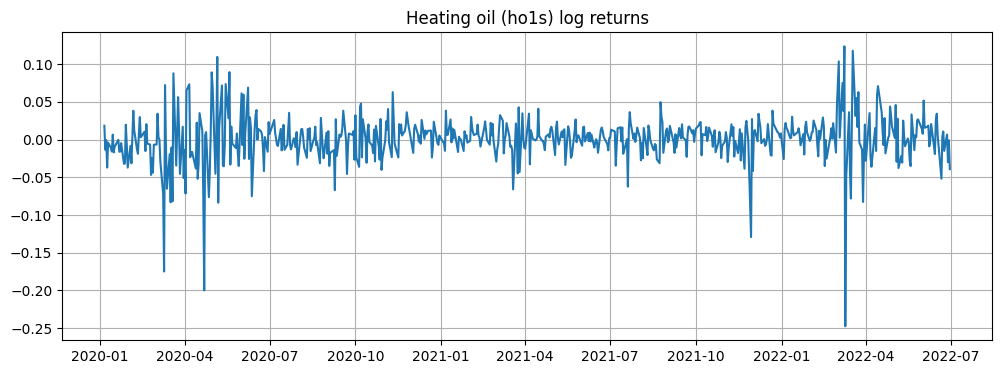

In [89]:
plt.figure(figsize=(12, 4))
plt.plot(heating_oil.index, heating_oil['logret_1d'])
plt.title('Heating oil (ho1s) log returns')
plt.grid(True)
plt.show()

In [90]:
base_cols = [
    'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d',
    'vol_of_vol_20d', 'vol_ratio_5_60',
    'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14',
    'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high',
    'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60',
    'trend_tstat_best', 'trend_H_best',
]
heating_oil[base_cols].tail()

,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,parkinson_20d,garman_klass_20d,vol_of_vol_20d,...,atr_14,adx_14,dd_from_60d_high,runup_from_60d_low,days_since_60d_high,trend_tstat_10,trend_tstat_20,trend_tstat_60,trend_tstat_best,trend_H_best
date,,,,,,,,,,,,,,,,,,,,,
2022-06-24,-0.015016,-0.046834,0.005698,0.171729,0.333064,0.022403,0.026035,0.028065,0.030394,0.001925,...,0.182136,28.013748,-0.050827,0.474442,4.0,-0.045950,5.871767,16.406592,16.406592,60.0
2022-06-27,0.006571,-0.045593,-0.008241,0.152688,0.358343,0.022043,0.025840,0.027878,0.030326,0.001838,...,0.175873,27.174847,-0.044570,0.484162,5.0,-0.197145,4.869147,16.182926,16.182926,60.0
2022-06-28,-0.030036,-0.023660,-0.029839,0.095966,0.308500,0.023087,0.026186,0.027881,0.030348,0.001713,...,0.173558,25.760322,-0.072840,0.440247,6.0,-1.128821,3.303068,15.645429,15.645429,60.0
2022-06-29,-0.001093,-0.029030,-0.011672,0.080741,0.335599,0.023014,0.025833,0.028994,0.031751,0.001545,...,0.179885,24.650561,-0.073853,0.438673,7.0,-3.282739,1.981078,15.008947,15.008947,60.0
2022-06-30,-0.039257,-0.078831,-0.076421,0.033908,0.277742,0.024937,0.026412,0.028618,0.030798,0.001667,...,0.182438,23.721758,-0.109506,0.383290,8.0,-5.717701,0.015677,13.906582,13.906582,60.0


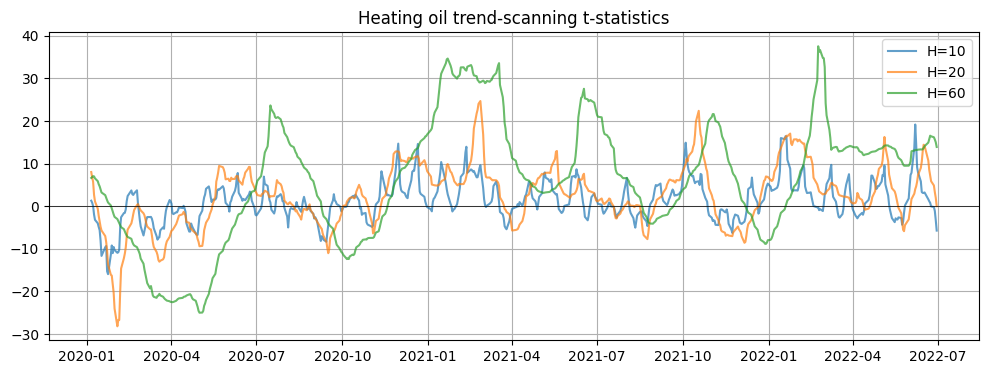

In [91]:
# Trend-scanning t-stats, Lecture 1, max |t| over several horizons
fig, ax = plt.subplots(figsize=(12, 4))
for h in [10, 20, 60]:
    ax.plot(heating_oil.index, heating_oil[f'trend_tstat_{h}'], label=f'H={h}', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Heating oil trend-scanning t-statistics')
ax.legend()
ax.grid(True)
plt.show()

## 4. Tier 2: Energy-Specific Features

Tier 2 adds features that are specific to the energy complex, for example crack spreads and cross-instrument spreads. Meta-labelling uses a secondary model to decide whether to act on the primary model's signal, and these features give that secondary model the energy-market context that a generic price feature would miss.

In [92]:
energy_cols = [
    'energy_basket_ret_5d', 'energy_basket_vol_20d',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'crack_321_proxy', 'crack_321_z_60d',
    'ho_cl_spread', 'rb_cl_spread',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'winter_indicator', 'driving_season',
]
heating_oil[energy_cols].tail()

,energy_basket_ret_5d,energy_basket_vol_20d,rel_ret_vs_basket_5d,corr_to_basket_60d,crack_321_proxy,crack_321_z_60d,ho_cl_spread,rb_cl_spread,month_sin,month_cos,dow_sin,dow_cos,winter_indicator,driving_season
date,,,,,,,,,,,,,,
2022-06-24,-0.082644,0.031510,0.035810,0.711436,0.000829,-0.164069,-2.127562,-1.151850,1.224647e-16,-1.0,-0.587785,-0.809017,0.0,1.0
2022-06-27,-0.076530,0.031862,0.030937,0.705382,-0.007808,-0.653094,-2.152614,-1.151036,1.224647e-16,-1.0,-0.951057,0.309017,0.0,1.0
2022-06-28,-0.014179,0.032228,-0.009481,0.692527,-0.035379,-2.143010,-2.200607,-1.180108,1.224647e-16,-1.0,0.000000,1.000000,0.0,1.0
2022-06-29,-0.001454,0.032284,-0.027576,0.679513,-0.001817,-0.235772,-2.221490,-1.172391,1.224647e-16,-1.0,0.951057,0.309017,0.0,1.0
2022-06-30,-0.025822,0.032777,-0.053009,0.689423,-0.016514,-1.046729,-2.242871,-1.186471,1.224647e-16,-1.0,0.587785,-0.809017,0.0,1.0


### 4.1 OVX Implied-Volatility Features

OVX is the CBOE Crude Oil Volatility Index, the oil-market analogue of VIX. Heating oil is a refined product priced largely off crude, so we use OVX as a broad forward-looking gauge of energy-market volatility, useful alongside the backward-looking `vol_20d`, `parkinson_20d`, and related features.

In this section we compute the following:
- `ovx_close` daily close
- `ovx_z` z-score on a 63-day window
- `iv_rv_ratio` implied vol (OVX) divided by realised vol (20-day annualised, in vol points)
- `ovx_slope` 5-day percentage change

**Why these features matter for meta-labelling**

The core idea is that options markets price in information that price-based features miss. When OVX is elevated, the market is paying up for crash protection, which usually means someone knows something or at least fears something. That is exactly the regime where a trend-following primary signal is most likely to get whipsawed.

`ovx_close` gives the raw implied vol level. On its own it is noisy, but it tells the meta-model whether the market is broadly calm or stressed. A bullish heating oil signal fired into a 50 plus OVX reading deserves a lot more scepticism than the same signal at OVX 25.

`ovx_z` normalises that level against the past 63 days. An OVX of 35 is unremarkable in a high-vol year but extreme in a quiet one. The z-score is what tells the meta-model whether the market is unusually fearful relative to its recent baseline, which is the number that matters for confidence calibration.

`iv_rv_ratio` is the most informative of the four. When implied vol runs well above realised vol, options are expensive and the market is pricing in a jump that has not happened yet. That tends to mean either a real catalyst is coming or the market is being irrational, and either way signal quality drops. When IV is below RV, options are cheap, the market has stopped hedging, and price action tends to be cleaner and more trend-friendly. The ratio is a direct read on how much the market trusts its own price signals.

`ovx_slope` captures whether fear is building or fading. A sharply rising OVX over 5 days, even from a moderate level, often precedes the kind of volatile, choppy price action that kills quantitative signals. A falling OVX after a spike is the opposite, the market is calming down and directional signals start working again. The slope gives the meta-model a sense of direction, not just level.

In [93]:
def load_ovx():
    """Return OVX close series indexed by date, or None if unavailable."""
    local = '../data/src/ovx.csv'
    df = pd.read_csv(local)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    close_col = 'Close' if 'Close' in df.columns else 'close'
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[close_col].rename('ovx_close').sort_index()


ovx_close = load_ovx()
if ovx_close is not None:
    ovx_close.index = pd.to_datetime(ovx_close.index).tz_localize(None)
    print('OVX rows:', len(ovx_close),
          'range:', ovx_close.index.min().date(), '→', ovx_close.index.max().date())
else:
    print('No OVX data available, subsequent OVX cells will be skipped.')

OVX rows: 4789 range: 2007-05-10 → 2026-05-21


In [94]:
if ovx_close is not None:
    ovx = ovx_close.to_frame()
    ovx['ovx_z'] = (
        (ovx['ovx_close'] - ovx['ovx_close'].rolling(63).mean())
        / ovx['ovx_close'].rolling(63).std()
    )
    ovx['ovx_slope'] = ovx['ovx_close'].pct_change(5)

    # iv_rv_ratio: implied (OVX, already in annualised vol points) over realised.
    # vol_20d is the std of daily logret, annualise by sqrt(252) and scale by 100 for vol points.
    rv_pts = heating_oil['vol_20d'] * np.sqrt(252) * 100
    ovx['iv_rv_ratio'] = ovx['ovx_close'] / rv_pts.reindex(ovx.index)

    heating_oil = heating_oil.join(ovx[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']], how='left')
    print(heating_oil[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']].dropna().tail())
else:
    print('Skipped: OVX not loaded.')

            ovx_close     ovx_z  iv_rv_ratio  ovx_slope
date                                                   
2022-06-24  46.990002 -0.948578     1.321293   0.015561
2022-06-27  46.990002 -0.974712     1.342865  -0.044724
2022-06-28  46.590000 -1.102164     1.271229   0.000644
2022-06-29  48.570000 -0.590286     1.329461  -0.008573
2022-06-30  48.900002 -0.479887     1.235268   0.006587


## 5. Tier 3: Latent Features

These are the latent regime features learned in notebook 1. They infer the hidden state the market is in rather than just describing what prices did.

**GMM**: a 3-component Gaussian mixture on `[vol_20d, vol_of_vol_20d, parkinson_20d]`, refit walk-forward every 63 trading days with a 504-day warmup. The components are re-sorted by mean vol after every refit, so `gmm_resp_low_vol` always means low vol regardless of how a refit shuffles the labels.

**HMM**: a 2-state Gaussian HMM (calm and turbulent) on `[logret_1d, vol_20d]`, trained walk-forward on the same schedule. We use filtering, not smoothing, so `hmm_filt_*` at time `t` only depends on data up to `t`. Calling `predict_proba` on a fitted HMM runs forward-backward and uses future data inside the training window, and we deliberately do not do that. `hmm_next_turbulent` is a one-step-ahead forecast, `hmm_regime_age` is the number of days since the regime last switched, and `hmm_basket_turbulent_energy` runs the same logic across the whole energy complex.

**K-means**: K=3 on the cross-section `[ret_5d, vol_20d, volume_z_20d]` of the energy complex per day. `kmeans_cluster_size` is the fraction of instruments sharing the same cluster, so a value near 1.0 means the whole complex is co-moving while a value near 0.25 means the instruments are behaving independently.

In [95]:
latent_cols = [
    'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp',
    'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age',
    'hmm_basket_turbulent_energy',
    'kmeans_cluster_id', 'kmeans_cluster_size',
]
heating_oil[latent_cols].tail()

,gmm_resp_low_vol,gmm_resp_med_vol,gmm_resp_high_vol,gmm_max_resp,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size
date,,,,,,,,,,,
2022-06-24,0.406280,0.588378,0.005343,1.0,0.014274,0.985726,0.964985,79.0,0.999979,2.0,0.5
2022-06-27,0.406524,0.587772,0.005704,1.0,0.019817,0.980183,0.959628,80.0,0.999921,0.0,0.5
2022-06-28,0.545075,0.451808,0.003117,0.0,0.002886,0.997114,0.975991,81.0,0.999909,2.0,0.5
2022-06-29,0.247226,0.743257,0.009517,1.0,0.006324,0.993676,0.972668,82.0,0.999930,2.0,0.5
2022-06-30,0.560649,0.436986,0.002365,0.0,0.000131,0.999869,0.978654,83.0,0.999981,2.0,0.5


## 6. Tier 4: Primary Signal Features

Tier 4 describes the primary signal itself, including its direction, its recent lags, and how long it has been firing the same way. The meta-model needs to know what the primary strategy is doing before it can judge whether to back it.

In [96]:
sig_cols = [
    'primary_signal',
    'primary_signal_lag1', 'primary_signal_lag5',
    'primary_signal_streak',
]
heating_oil[sig_cols].dropna().head(10)

,primary_signal,primary_signal_lag1,primary_signal_lag5,primary_signal_streak
date,,,,
2020-01-13,0.0,0.0,0.0,5.0
2020-01-14,0.0,0.0,0.0,6.0
2020-01-15,0.0,0.0,0.0,7.0
2020-01-16,0.0,0.0,0.0,8.0
2020-01-17,0.0,0.0,0.0,9.0
2020-01-21,1.0,0.0,0.0,10.0
2020-01-22,0.0,0.0,0.0,0.0
2020-01-23,1.0,1.0,0.0,1.0
2020-01-24,0.0,0.0,0.0,2.0


## 7. Dimensionality Reduction and Regime Filtering

Here we handle the downstream steps. We split the data at the signal start date, group the correlated features into clusters, reduce each cluster to a single factor with a within-cluster principal component, add the forward-only HMM regime probabilities, and pass the result to the models. The aim is to cut the feature count down to a small set of interpretable factors so the model stays stable on a small sample and we can still say which feature group drives it.

**Why clustering rather than a single global PCA**

With many more candidate features than labelled rows, some dimensionality control is needed or the model overfits. A global PCA would do that, but it rotates every feature into dense components, so the inputs stop being interpretable and the leading components can be dominated by whichever block of features happens to carry the most variance. Grouping correlated features and taking one principal component within each group gives the same denoising and an even smaller feature count, while keeping every factor tied to a named theme. That interpretability is exactly what the cluster-level importance analysis later in the project depends on.

**Filtering over smoothing**

The HMM that runs on these factors uses the forward algorithm only. The forward-backward algorithm that standard implementations use for `predict_proba` is a smoother, so the probability assigned to time `t` depends on observations both before and after `t`. That is fine for offline analysis but fatal for a trading model, since it means today's regime label was partly determined by tomorrow's returns. Using the forward pass only means the regime probabilities are genuine real-time estimates.

**Why a 70/30 train/test split**

The split is reserved purely for final evaluation, the test set is never touched during tuning. The primary signal data begins in 2020, but the feature pipeline has a 504-day warmup before the first GMM, HMM, and PCA refit fires, which consumes roughly two years before a single fully-featured labelled observation is available. That is why `SIGNAL_START = '2021-08-16'` sits where it does, and a 70/30 split on that effective window gives roughly two years of training and just under one year of test data. Triple-barrier labelling shrinks the sample further, since it only fires when the primary signal is non-zero and many entries hit the time barrier, so going to 80/20 would push the test set down to a point where the standard error of AUC is nearly as wide as the signal itself. The 5-fold walk-forward CV on the training set does the heavy lifting for model selection, and a 70% training allocation gives each fold enough data to produce a meaningful AUC estimate.

The honest limitation is that a single temporal split means the test set covers one specific market period. If that period happens to be unusually calm or unusually stressed, the test AUC will not reflect long-run performance. The right way to read the results is as how the meta-model would have performed had it gone live at the split date, not as a claim about universal performance.

In [97]:
SIGNAL_START = '2021-08-16'

# Feature set fed into the clustering and the downstream models.
# Base and energy features, plus OVX, plus the Tier 3 latent and Tier 4 signal features.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in section 4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in heating_oil.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

# Add the Tier 3 latent regime features and the Tier 4 primary-signal features.
downstream_cols += [c for c in latent_cols + sig_cols if c in heating_oil.columns]

X = heating_oil[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape, '| features:', len(downstream_cols))

Including OVX features: ['ovx_z', 'iv_rv_ratio', 'ovx_slope']
train: (401, 38) test: (221, 38) | features: 38


### 7.1 Feature Clustering

Instead of one PCA over the whole feature set, we group the features by how correlated they are, so each group can later be summarised and interrogated as a unit. We measure similarity with the Spearman correlation, which is robust to the fat tails in return data, and convert it to the Lopez de Prado distance `d = sqrt(0.5 (1 - rho))`, which is a proper metric. We then run average-linkage hierarchical clustering and cut the tree at a correlation threshold, so two features only share a cluster if they are genuinely correlated.

The silhouette curve here is flat, which tells us there is no single best number of clusters, so picking a fixed k would force unrelated features together and leave clusters that one principal component cannot summarise well. Cutting at a correlation level instead respects the real structure and keeps every cluster tight, so its first principal component stays a faithful summary. `CORR_THRESHOLD` is the one knob, raise it for tighter and more numerous groups, lower it for fewer and broader ones. Everything here is fit on the training window only, and the silhouette curve and dendrogram are shown as diagnostics.

CORR_THRESHOLD = 0.4  ->  20 clusters


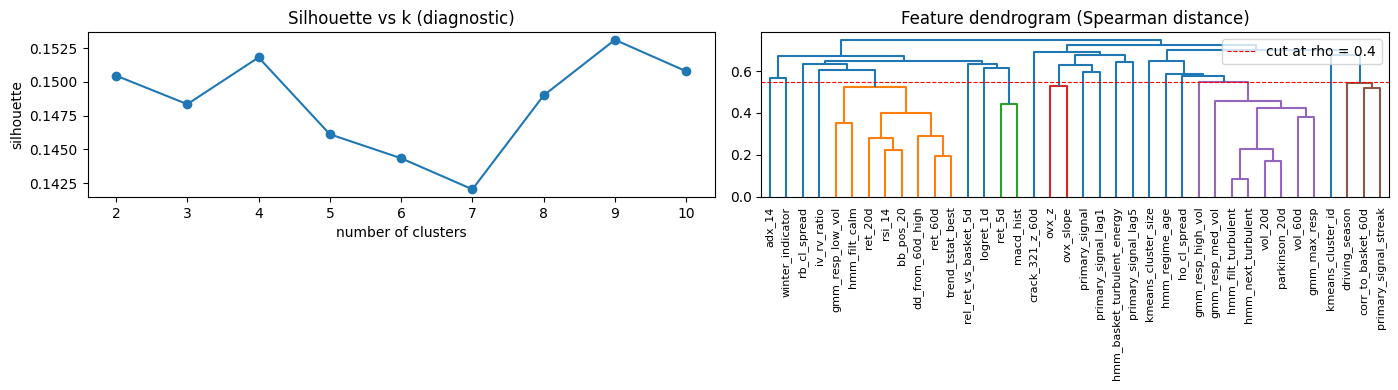

In [98]:
# Cluster the features by their correlation, on the training window only (no leakage).
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# keep only features that actually vary in the training window
cluster_feats = [c for c in X_train.columns if X_train[c].std() > 0]

# Spearman correlation -> Lopez de Prado distance d = sqrt(0.5 (1 - rho))
corr = X_train[cluster_feats].corr(method='spearman')
dist = np.sqrt(0.5 * (1 - corr)).clip(lower=0)
Z = linkage(squareform(dist.values, checks=False), method='average')

# Cut the tree at a correlation threshold, so features only share a cluster if they
# are genuinely correlated. Raise CORR_THRESHOLD for tighter, more numerous groups,
# lower it for fewer, broader ones.
CORR_THRESHOLD = 0.4
dist_cut = np.sqrt(0.5 * (1 - CORR_THRESHOLD))
cluster_id = pd.Series(fcluster(Z, dist_cut, criterion='distance'),
                       index=cluster_feats, name='cluster')
print(f'CORR_THRESHOLD = {CORR_THRESHOLD}  ->  {cluster_id.nunique()} clusters')

# Silhouette curve, kept only as a diagnostic. A flat curve means there is no single best k.
sil = {}
for k in range(2, min(11, len(cluster_feats))):
    labels_k = fcluster(Z, k, criterion='maxclust')
    if len(np.unique(labels_k)) < 2:
        continue
    sil[k] = silhouette_score(dist.values, labels_k, metric='precomputed')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(sil.keys()), list(sil.values()), marker='o')
ax[0].set_xlabel('number of clusters')
ax[0].set_ylabel('silhouette')
ax[0].set_title('Silhouette vs k (diagnostic)')
dendrogram(Z, labels=cluster_feats, ax=ax[1], leaf_rotation=90, color_threshold=dist_cut)
ax[1].axhline(dist_cut, color='red', ls='--', lw=0.8, label=f'cut at rho = {CORR_THRESHOLD}')
ax[1].legend()
ax[1].set_title('Feature dendrogram (Spearman distance)')
plt.tight_layout()
plt.show()

### 7.2 Cluster Composition and Names

We list the features in each cluster and attach a readable name from the dominant theme of its members, for example volatility, momentum, energy spreads or implied vol. The names are only a suggestion, the `cluster_names` dictionary can be edited if a label does not fit. These names carry through to the factor columns and to the cluster-level importance analysis later on.

In [99]:
# Show the members of each cluster and auto-suggest a readable name from the dominant theme.
THEME = {
    'logret_1d': 'returns', 'ret_5d': 'returns', 'ret_20d': 'returns', 'ret_60d': 'returns',
    'vol_20d': 'volatility', 'vol_60d': 'volatility', 'parkinson_20d': 'volatility', 'vol_of_vol_20d': 'volatility',
    'rsi_14': 'oscillators', 'macd_hist': 'oscillators', 'bb_pos_20': 'oscillators',
    'adx_14': 'trend', 'trend_tstat_best': 'trend', 'dd_from_60d_high': 'drawdown',
    'crack_321_z_60d': 'energy_spreads', 'ho_cl_spread': 'energy_spreads', 'rb_cl_spread': 'energy_spreads',
    'rel_ret_vs_basket_5d': 'cross_sectional', 'corr_to_basket_60d': 'cross_sectional',
    'winter_indicator': 'seasonality', 'driving_season': 'seasonality',
    'ovx_z': 'implied_vol', 'iv_rv_ratio': 'implied_vol', 'ovx_slope': 'implied_vol',
    'gmm_resp_low_vol': 'regime', 'gmm_resp_med_vol': 'regime', 'gmm_resp_high_vol': 'regime', 'gmm_max_resp': 'regime',
    'hmm_filt_calm': 'regime', 'hmm_filt_turbulent': 'regime', 'hmm_next_turbulent': 'regime',
    'hmm_regime_age': 'regime', 'hmm_basket_turbulent_energy': 'regime',
    'kmeans_cluster_id': 'regime', 'kmeans_cluster_size': 'regime',
    'primary_signal': 'signal', 'primary_signal_lag1': 'signal', 'primary_signal_lag5': 'signal', 'primary_signal_streak': 'signal',
}

cluster_names, used = {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    themes = pd.Series([THEME.get(m, 'other') for m in members]).value_counts()
    name = themes.index[0]
    if len(themes) > 1 and themes.iloc[1] == themes.iloc[0]:
        name = f'{themes.index[0]}_{themes.index[1]}'   # tie, combine the top two themes
    used[name] = used.get(name, 0) + 1
    if used[name] > 1:
        name = f'{name}_{used[name]}'                    # keep the names unique
    cluster_names[c] = name
    print(f'cluster {c:>2}  ->  {name:<22} {members}')

# Edit cluster_names here if any auto-suggested label does not fit.

cluster  1  ->  trend                  ['adx_14']
cluster  2  ->  seasonality            ['winter_indicator']
cluster  3  ->  returns_oscillators    ['ret_20d', 'ret_60d', 'rsi_14', 'bb_pos_20', 'dd_from_60d_high', 'trend_tstat_best', 'gmm_resp_low_vol', 'hmm_filt_calm']
cluster  4  ->  implied_vol            ['iv_rv_ratio']
cluster  5  ->  energy_spreads         ['rb_cl_spread']
cluster  6  ->  returns_oscillators_2  ['ret_5d', 'macd_hist']
cluster  7  ->  returns                ['logret_1d']
cluster  8  ->  cross_sectional        ['rel_ret_vs_basket_5d']
cluster  9  ->  implied_vol_2          ['ovx_z', 'ovx_slope']
cluster 10  ->  signal                 ['primary_signal']
cluster 11  ->  signal_2               ['primary_signal_lag1']
cluster 12  ->  regime                 ['hmm_basket_turbulent_energy']
cluster 13  ->  signal_3               ['primary_signal_lag5']
cluster 14  ->  energy_spreads_2       ['crack_321_z_60d']
cluster 15  ->  regime_2               ['vol_20d', 'vol_60d',

### 7.3 Within-Cluster PC1

Each cluster is reduced to a single factor, the first principal component taken within that cluster. This keeps the denoising benefit of PCA but ties every factor to one named group, so we can still say which group drives the model. We sign-align each component to its cluster mean so a higher value has a consistent meaning, and we report how much of the cluster variance the first component captures. The scaler and the components are fit on the training window and then applied to the test window.

**Why a RobustScaler.** Everywhere we standardise features in this notebook (before the within-cluster PCA here, and again for the logistic-regression and neural-network inputs in Section 9) we use a `RobustScaler` (centre on the median, scale by the interquartile range) rather than a `StandardScaler`. Heating oil returns are fat-tailed and event-driven, so a few extreme sessions would inflate the standard deviation and squash the rest of the distribution, whereas the median and IQR are barely moved by those outliers. The bulk of the data is therefore scaled consistently and no single shock day dominates the PCA or the model inputs.

In [100]:
# Reduce each cluster to a single factor, the first principal component within that cluster.
# The scaler, the clustering and the sign alignment are all fit on the training window only.
scaler = RobustScaler()
Xtr_s = pd.DataFrame(scaler.fit_transform(X_train[cluster_feats]), index=X_train.index, columns=cluster_feats)
Xte_s = pd.DataFrame(scaler.transform(X_test[cluster_feats]),      index=X_test.index,  columns=cluster_feats)

cluster_pca, evr, train_fac, test_fac = {}, {}, {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    p = PCA(n_components=1, random_state=42)
    tr = p.fit_transform(Xtr_s[members]).ravel()
    te = p.transform(Xte_s[members]).ravel()
    if np.corrcoef(tr, Xtr_s[members].mean(axis=1))[0, 1] < 0:   # sign-align to the cluster mean
        tr, te = -tr, -te
    name = cluster_names[c]
    train_fac[name], test_fac[name] = tr, te
    evr[name] = p.explained_variance_ratio_[0]
    cluster_pca[c] = p

train_pca_df = pd.DataFrame(train_fac, index=X_train.index)
test_pca_df  = pd.DataFrame(test_fac,  index=X_test.index)
X_train_pca, X_test_pca = train_pca_df.values, test_pca_df.values
pc_cols = list(train_pca_df.columns)

print('cluster factors:', pc_cols)
print('PC1 variance explained per cluster:', {k: round(v, 2) for k, v in evr.items()})
print(f'reduced from {len(cluster_feats)} features to {len(pc_cols)} cluster factors')
train_pca_df.head()

cluster factors: ['trend', 'seasonality', 'returns_oscillators', 'implied_vol', 'energy_spreads', 'returns_oscillators_2', 'returns', 'cross_sectional', 'implied_vol_2', 'signal', 'signal_2', 'regime', 'signal_3', 'energy_spreads_2', 'regime_2', 'energy_spreads_3', 'regime_3', 'regime_4', 'cross_sectional_seasonality', 'regime_5']
PC1 variance explained per cluster: {'trend': 1.0, 'seasonality': 1.0, 'returns_oscillators': 0.73, 'implied_vol': 1.0, 'energy_spreads': 1.0, 'returns_oscillators_2': 0.82, 'returns': 1.0, 'cross_sectional': 1.0, 'implied_vol_2': 0.88, 'signal': 1.0, 'signal_2': 1.0, 'regime': 1.0, 'signal_3': 1.0, 'energy_spreads_2': 1.0, 'regime_2': 1.0, 'energy_spreads_3': 1.0, 'regime_3': 1.0, 'regime_4': 1.0, 'cross_sectional_seasonality': 0.69, 'regime_5': 1.0}
reduced from 38 features to 20 cluster factors


,trend,seasonality,returns_oscillators,implied_vol,energy_spreads,returns_oscillators_2,returns,cross_sectional,implied_vol_2,signal,signal_2,regime,signal_3,energy_spreads_2,regime_2,energy_spreads_3,regime_3,regime_4,cross_sectional_seasonality,regime_5
date,,,,,,,,,,,,,,,,,,,,
2020-01-13,-0.013937,0.715711,0.076489,0.374895,-1.048205,-1.637020,-0.406658,-0.966992,0.291699,-0.049875,-0.049875,0.575557,-0.049875,1.061484,-96.069952,-2.183404,0.499537,0.582294,-0.907142,-0.466334
2020-01-14,-0.032029,0.715711,-0.192716,0.287833,-0.906933,-1.849464,-0.581330,-0.726748,0.254017,-0.049875,-0.049875,0.575452,-0.049875,1.300903,-96.085320,-2.172994,0.528108,0.582294,-0.839628,-0.466334
2020-01-15,-0.065789,0.715711,-0.225778,0.412517,-0.947701,-1.779320,0.249286,-0.697572,0.062890,-0.049875,-0.049875,0.575741,-0.049875,-0.139561,-95.982841,-2.092832,0.556680,0.582294,-0.831663,-0.466334
2020-01-16,-0.113059,0.715711,-0.478849,0.084142,-0.980273,-1.574013,-0.626531,-0.651725,-0.838385,-0.049875,-0.049875,0.575117,-0.049875,-0.612688,-96.003798,-2.296756,0.585251,0.082294,-0.790668,-0.466334
2020-01-17,-0.191069,0.715711,-0.641682,0.114166,-0.988951,-1.705820,-0.346735,-0.697751,-0.650579,-0.049875,-0.049875,0.575723,-0.049875,-0.857445,-95.772522,-2.739610,0.613823,-0.417706,-0.766199,-0.466334


### 7.4 HMM Regime Filtering

We choose the number of hidden states with a BIC sweep, fitting candidate models with 2 to 5 states and several random seeds and keeping the lowest BIC. We then run the forward algorithm by hand to obtain filtering posteriors on the cluster factors. Filtering uses only past and present data, unlike the smoothing that `predict_proba` would apply, so the regime probabilities that feed the meta-model stay free of look-ahead. We also compute a one-step-ahead forecast by pushing the current filtered state through the transition matrix.

In [101]:
# BIC sweep for the optimal number of HMM states, capped at 5

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

Model is not converging.  Current: -8188.58971962442 is not greater than -8188.575991061249. Delta is -0.0137285631708437
Model is not converging.  Current: -8188.593518929314 is not greater than -8188.576760096867. Delta is -0.016758832447521854
Model is not converging.  Current: -5782.653858063968 is not greater than -5781.8206477875365. Delta is -0.8332102764316005
Model is not converging.  Current: -7270.392009268778 is not greater than -7270.384787662324. Delta is -0.007221606453640561
Model is not converging.  Current: -7271.940941042948 is not greater than -7271.935779832839. Delta is -0.005161210108781233
Model is not converging.  Current: -8546.864800290388 is not greater than -8546.856271728191. Delta is -0.008528562197170686


K=2: BIC=16,874.7
K=3: BIC=12,333.0


Model is not converging.  Current: -5041.303655008124 is not greater than -5041.066435155589. Delta is -0.23721985253541789
Model is not converging.  Current: -8134.806760499307 is not greater than -8134.7212927050205. Delta is -0.08546779428615991
Model is not converging.  Current: -7247.646422392803 is not greater than -7247.635500725117. Delta is -0.010921667686488945
Model is not converging.  Current: -5700.568523091736 is not greater than -5700.41146177127. Delta is -0.15706132046580024
Model is not converging.  Current: -6339.2716375532655 is not greater than -6339.271580997278. Delta is -5.655598761222791e-05


K=4: BIC=11,131.8
K=5: BIC=9,658.9
Chosen K = 5


In [102]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,trend,seasonality,returns_oscillators,implied_vol,energy_spreads,returns_oscillators_2,returns,cross_sectional,implied_vol_2,signal,...,energy_spreads_3,regime_3,regime_4,cross_sectional_seasonality,regime_5,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,,,,,
2020-01-13,-0.013937,0.715711,0.076489,0.374895,-1.048205,-1.637020,-0.406658,-0.966992,0.291699,-0.049875,...,-2.183404,0.499537,0.582294,-0.907142,-0.466334,9.123210e-74,0.0,0.0,0.0,1.000000
2020-01-14,-0.032029,0.715711,-0.192716,0.287833,-0.906933,-1.849464,-0.581330,-0.726748,0.254017,-0.049875,...,-2.172994,0.528108,0.582294,-0.839628,-0.466334,1.088242e-05,0.0,0.0,0.0,0.999989
2020-01-15,-0.065789,0.715711,-0.225778,0.412517,-0.947701,-1.779320,0.249286,-0.697572,0.062890,-0.049875,...,-2.092832,0.556680,0.582294,-0.831663,-0.466334,7.047858e-06,0.0,0.0,0.0,0.999993
2020-01-16,-0.113059,0.715711,-0.478849,0.084142,-0.980273,-1.574013,-0.626531,-0.651725,-0.838385,-0.049875,...,-2.296756,0.585251,0.082294,-0.790668,-0.466334,8.082402e-06,0.0,0.0,0.0,0.999992
2020-01-17,-0.191069,0.715711,-0.641682,0.114166,-0.988951,-1.705820,-0.346735,-0.697751,-0.650579,-0.049875,...,-2.739610,0.613823,-0.417706,-0.766199,-0.466334,2.159776e-05,0.0,0.0,0.0,0.999978


## 8. Triple-Barrier Meta-Labels

We label each primary signal with the triple-barrier method. A trade counts as a win if the profit-taking barrier is reached before the stop-loss or the time limit. These labels become the target the meta-model learns to predict for heating oil.

**Why these barrier choices make sense for heating oil**

**Volatility scaling with EWM span 20:** The daily vol estimate uses a 20-day exponentially weighted standard deviation of log returns, and the exponential weighting is deliberate. The heating oil market is event-driven. A surprise EIA inventory print, a cold-weather forecast, or a sharp move in crude can lift realised vol quickly. A simple rolling standard deviation treats every observation equally, so a spike three weeks ago carries the same weight as yesterday, whereas the EWM decays older observations so the vol estimate at trade entry reflects the current regime rather than a stale average. The 20-day span sits at roughly one trading month, long enough to avoid noise from a single session but short enough to adapt within a few weeks when the regime genuinely shifts.

**Symmetric barriers at pt_sl = [1.5, 1.5]:** The symmetry is intentional, it means the label is not pre-tilted toward wins or losses by construction. If the profit-take were wider than the stop-loss, the win rate would be inflated and the meta-label distribution would be harder to interpret. The 1.5 multiplier reflects heating oil's return distribution, which has fat tails and persistent ranges. A multiplier of 1.0 would set barriers just one standard deviation from entry, which gets hit constantly by noise rather than genuine directional moves, while a multiplier of 2.0 or higher would push too many trades to the time barrier and degrade label quality.

**Maximum hold of 20 days:** Twenty trading days is one calendar month, which is the right horizon for a trend-following signal on an energy instrument. Signals based on regime state, energy spreads, and trend-scanning t-statistics pick up moves that play out over days to weeks, not hours, so a 5-day hold is too short for them to resolve. A 60-day hold would introduce roll risk and force the model to hold through multiple EIA reports, swings in crude, and seasonal demand transitions, all of which can reverse the original signal rationale. The EIA weekly petroleum status report lands every Wednesday, so 20 trading days covers roughly four report cycles. A signal that has not resolved after four of those cycles has probably lost its original context. A shorter hold would also push more labels to the time barrier, producing ambiguous outcomes for trades that were neither right nor wrong, so 20 days gives a reasonable fraction of clean barrier touches, which is what a well-calibrated meta-label dataset needs.

## 7. Dimensionality Reduction and Regime Filtering

Here we handle the downstream steps. We split the data at the signal start date, group the correlated features into clusters, reduce each cluster to a single factor with a within-cluster principal component, add the forward-only HMM regime probabilities, and pass the result to the models. The aim is to cut the feature count down to a small set of interpretable factors so the model stays stable on a small sample and we can still say which feature group drives it.

**Why clustering rather than a single global PCA**

With many more candidate features than labelled rows, some dimensionality control is needed or the model overfits. A global PCA would do that, but it rotates every feature into dense components, so the inputs stop being interpretable and the leading components can be dominated by whichever block of features happens to carry the most variance. Grouping correlated features and taking one principal component within each group gives the same denoising and an even smaller feature count, while keeping every factor tied to a named theme. That interpretability is exactly what the cluster-level importance analysis later in the project depends on.

**Filtering over smoothing**

The HMM that runs on these factors uses the forward algorithm only. The forward-backward algorithm that standard implementations use for `predict_proba` is a smoother, so the probability assigned to time `t` depends on observations both before and after `t`. That is fine for offline analysis but fatal for a trading model, since it means today's regime label was partly determined by tomorrow's returns. Using the forward pass only means the regime probabilities are genuine real-time estimates.

**Why a 70/30 train/test split**

The split is reserved purely for final evaluation, the test set is never touched during tuning. The primary signal data begins in 2020, but the feature pipeline has a 504-day warmup before the first GMM, HMM, and PCA refit fires, which consumes roughly two years before a single fully-featured labelled observation is available. That is why `SIGNAL_START = '2021-08-16'` sits where it does, and a 70/30 split on that effective window gives roughly two years of training and just under one year of test data. Triple-barrier labelling shrinks the sample further, since it only fires when the primary signal is non-zero and many entries hit the time barrier, so going to 80/20 would push the test set down to a point where the standard error of AUC is nearly as wide as the signal itself. The 5-fold walk-forward CV on the training set does the heavy lifting for model selection, and a 70% training allocation gives each fold enough data to produce a meaningful AUC estimate.

The honest limitation is that a single temporal split means the test set covers one specific market period. If that period happens to be unusually calm or unusually stressed, the test AUC will not reflect long-run performance. The right way to read the results is as how the meta-model would have performed had it gone live at the split date, not as a claim about universal performance.

In [103]:
SIGNAL_START = '2021-08-16'

# Feature set fed into the clustering and the downstream models.
# Base and energy features, plus OVX, plus the Tier 3 latent and Tier 4 signal features.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in section 4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in heating_oil.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

# Add the Tier 3 latent regime features and the Tier 4 primary-signal features.
downstream_cols += [c for c in latent_cols + sig_cols if c in heating_oil.columns]

X = heating_oil[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape, '| features:', len(downstream_cols))

Including OVX features: ['ovx_z', 'iv_rv_ratio', 'ovx_slope']
train: (401, 38) test: (221, 38) | features: 38


### 7.1 Feature Clustering

Instead of one PCA over the whole feature set, we group the features by how correlated they are, so each group can later be summarised and interrogated as a unit. We measure similarity with the Spearman correlation, which is robust to the fat tails in return data, and convert it to the Lopez de Prado distance `d = sqrt(0.5 (1 - rho))`, which is a proper metric. We then run average-linkage hierarchical clustering and cut the tree at a correlation threshold, so two features only share a cluster if they are genuinely correlated.

The silhouette curve here is flat, which tells us there is no single best number of clusters, so picking a fixed k would force unrelated features together and leave clusters that one principal component cannot summarise well. Cutting at a correlation level instead respects the real structure and keeps every cluster tight, so its first principal component stays a faithful summary. `CORR_THRESHOLD` is the one knob, raise it for tighter and more numerous groups, lower it for fewer and broader ones. Everything here is fit on the training window only, and the silhouette curve and dendrogram are shown as diagnostics.

CORR_THRESHOLD = 0.4  ->  20 clusters


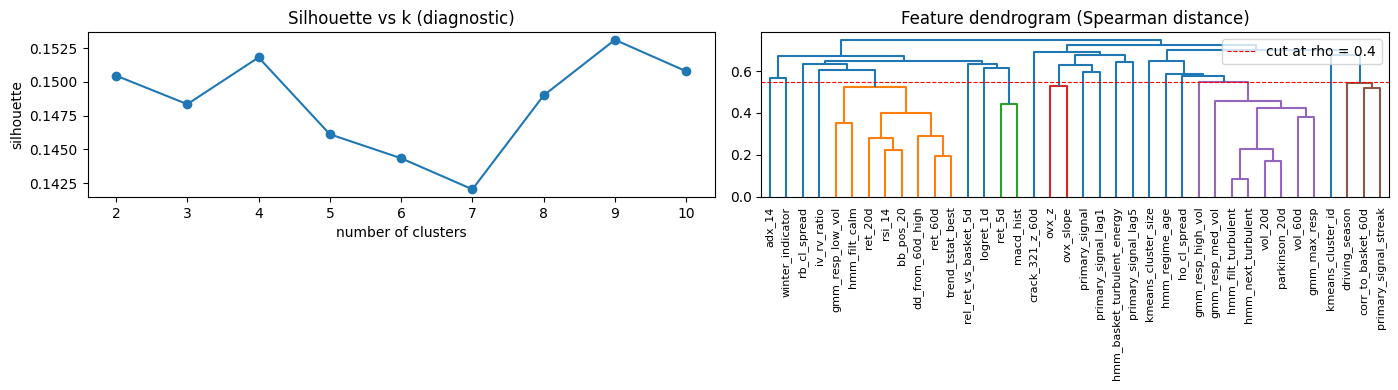

In [104]:
# Cluster the features by their correlation, on the training window only (no leakage).
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# keep only features that actually vary in the training window
cluster_feats = [c for c in X_train.columns if X_train[c].std() > 0]

# Spearman correlation -> Lopez de Prado distance d = sqrt(0.5 (1 - rho))
corr = X_train[cluster_feats].corr(method='spearman')
dist = np.sqrt(0.5 * (1 - corr)).clip(lower=0)
Z = linkage(squareform(dist.values, checks=False), method='average')

# Cut the tree at a correlation threshold, so features only share a cluster if they
# are genuinely correlated. Raise CORR_THRESHOLD for tighter, more numerous groups,
# lower it for fewer, broader ones.
CORR_THRESHOLD = 0.4
dist_cut = np.sqrt(0.5 * (1 - CORR_THRESHOLD))
cluster_id = pd.Series(fcluster(Z, dist_cut, criterion='distance'),
                       index=cluster_feats, name='cluster')
print(f'CORR_THRESHOLD = {CORR_THRESHOLD}  ->  {cluster_id.nunique()} clusters')

# Silhouette curve, kept only as a diagnostic. A flat curve means there is no single best k.
sil = {}
for k in range(2, min(11, len(cluster_feats))):
    labels_k = fcluster(Z, k, criterion='maxclust')
    if len(np.unique(labels_k)) < 2:
        continue
    sil[k] = silhouette_score(dist.values, labels_k, metric='precomputed')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(sil.keys()), list(sil.values()), marker='o')
ax[0].set_xlabel('number of clusters')
ax[0].set_ylabel('silhouette')
ax[0].set_title('Silhouette vs k (diagnostic)')
dendrogram(Z, labels=cluster_feats, ax=ax[1], leaf_rotation=90, color_threshold=dist_cut)
ax[1].axhline(dist_cut, color='red', ls='--', lw=0.8, label=f'cut at rho = {CORR_THRESHOLD}')
ax[1].legend()
ax[1].set_title('Feature dendrogram (Spearman distance)')
plt.tight_layout()
plt.show()

### 7.2 Cluster Composition and Names

We list the features in each cluster and attach a readable name from the dominant theme of its members, for example volatility, momentum, energy spreads or implied vol. The names are only a suggestion, the `cluster_names` dictionary can be edited if a label does not fit. These names carry through to the factor columns and to the cluster-level importance analysis later on.

In [105]:
# Show the members of each cluster and auto-suggest a readable name from the dominant theme.
THEME = {
    'logret_1d': 'returns', 'ret_5d': 'returns', 'ret_20d': 'returns', 'ret_60d': 'returns',
    'vol_20d': 'volatility', 'vol_60d': 'volatility', 'parkinson_20d': 'volatility', 'vol_of_vol_20d': 'volatility',
    'rsi_14': 'oscillators', 'macd_hist': 'oscillators', 'bb_pos_20': 'oscillators',
    'adx_14': 'trend', 'trend_tstat_best': 'trend', 'dd_from_60d_high': 'drawdown',
    'crack_321_z_60d': 'energy_spreads', 'ho_cl_spread': 'energy_spreads', 'rb_cl_spread': 'energy_spreads',
    'rel_ret_vs_basket_5d': 'cross_sectional', 'corr_to_basket_60d': 'cross_sectional',
    'winter_indicator': 'seasonality', 'driving_season': 'seasonality',
    'ovx_z': 'implied_vol', 'iv_rv_ratio': 'implied_vol', 'ovx_slope': 'implied_vol',
    'gmm_resp_low_vol': 'regime', 'gmm_resp_med_vol': 'regime', 'gmm_resp_high_vol': 'regime', 'gmm_max_resp': 'regime',
    'hmm_filt_calm': 'regime', 'hmm_filt_turbulent': 'regime', 'hmm_next_turbulent': 'regime',
    'hmm_regime_age': 'regime', 'hmm_basket_turbulent_energy': 'regime',
    'kmeans_cluster_id': 'regime', 'kmeans_cluster_size': 'regime',
    'primary_signal': 'signal', 'primary_signal_lag1': 'signal', 'primary_signal_lag5': 'signal', 'primary_signal_streak': 'signal',
}

cluster_names, used = {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    themes = pd.Series([THEME.get(m, 'other') for m in members]).value_counts()
    name = themes.index[0]
    if len(themes) > 1 and themes.iloc[1] == themes.iloc[0]:
        name = f'{themes.index[0]}_{themes.index[1]}'   # tie, combine the top two themes
    used[name] = used.get(name, 0) + 1
    if used[name] > 1:
        name = f'{name}_{used[name]}'                    # keep the names unique
    cluster_names[c] = name
    print(f'cluster {c:>2}  ->  {name:<22} {members}')

# Edit cluster_names here if any auto-suggested label does not fit.

cluster  1  ->  trend                  ['adx_14']
cluster  2  ->  seasonality            ['winter_indicator']
cluster  3  ->  returns_oscillators    ['ret_20d', 'ret_60d', 'rsi_14', 'bb_pos_20', 'dd_from_60d_high', 'trend_tstat_best', 'gmm_resp_low_vol', 'hmm_filt_calm']
cluster  4  ->  implied_vol            ['iv_rv_ratio']
cluster  5  ->  energy_spreads         ['rb_cl_spread']
cluster  6  ->  returns_oscillators_2  ['ret_5d', 'macd_hist']
cluster  7  ->  returns                ['logret_1d']
cluster  8  ->  cross_sectional        ['rel_ret_vs_basket_5d']
cluster  9  ->  implied_vol_2          ['ovx_z', 'ovx_slope']
cluster 10  ->  signal                 ['primary_signal']
cluster 11  ->  signal_2               ['primary_signal_lag1']
cluster 12  ->  regime                 ['hmm_basket_turbulent_energy']
cluster 13  ->  signal_3               ['primary_signal_lag5']
cluster 14  ->  energy_spreads_2       ['crack_321_z_60d']
cluster 15  ->  regime_2               ['vol_20d', 'vol_60d',

### 7.3 Within-Cluster PC1

Each cluster is reduced to a single factor, the first principal component taken within that cluster. This keeps the denoising benefit of PCA but ties every factor to one named group, so we can still say which group drives the model. We sign-align each component to its cluster mean so a higher value has a consistent meaning, and we report how much of the cluster variance the first component captures. The scaler and the components are fit on the training window and then applied to the test window.

In [106]:
# Reduce each cluster to a single factor, the first principal component within that cluster.
# The scaler, the clustering and the sign alignment are all fit on the training window only.
scaler = RobustScaler()
Xtr_s = pd.DataFrame(scaler.fit_transform(X_train[cluster_feats]), index=X_train.index, columns=cluster_feats)
Xte_s = pd.DataFrame(scaler.transform(X_test[cluster_feats]),      index=X_test.index,  columns=cluster_feats)

cluster_pca, evr, train_fac, test_fac = {}, {}, {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    p = PCA(n_components=1, random_state=42)
    tr = p.fit_transform(Xtr_s[members]).ravel()
    te = p.transform(Xte_s[members]).ravel()
    if np.corrcoef(tr, Xtr_s[members].mean(axis=1))[0, 1] < 0:   # sign-align to the cluster mean
        tr, te = -tr, -te
    name = cluster_names[c]
    train_fac[name], test_fac[name] = tr, te
    evr[name] = p.explained_variance_ratio_[0]
    cluster_pca[c] = p

train_pca_df = pd.DataFrame(train_fac, index=X_train.index)
test_pca_df  = pd.DataFrame(test_fac,  index=X_test.index)
X_train_pca, X_test_pca = train_pca_df.values, test_pca_df.values
pc_cols = list(train_pca_df.columns)

print('cluster factors:', pc_cols)
print('PC1 variance explained per cluster:', {k: round(v, 2) for k, v in evr.items()})
print(f'reduced from {len(cluster_feats)} features to {len(pc_cols)} cluster factors')
train_pca_df.head()

cluster factors: ['trend', 'seasonality', 'returns_oscillators', 'implied_vol', 'energy_spreads', 'returns_oscillators_2', 'returns', 'cross_sectional', 'implied_vol_2', 'signal', 'signal_2', 'regime', 'signal_3', 'energy_spreads_2', 'regime_2', 'energy_spreads_3', 'regime_3', 'regime_4', 'cross_sectional_seasonality', 'regime_5']
PC1 variance explained per cluster: {'trend': 1.0, 'seasonality': 1.0, 'returns_oscillators': 0.73, 'implied_vol': 1.0, 'energy_spreads': 1.0, 'returns_oscillators_2': 0.82, 'returns': 1.0, 'cross_sectional': 1.0, 'implied_vol_2': 0.88, 'signal': 1.0, 'signal_2': 1.0, 'regime': 1.0, 'signal_3': 1.0, 'energy_spreads_2': 1.0, 'regime_2': 1.0, 'energy_spreads_3': 1.0, 'regime_3': 1.0, 'regime_4': 1.0, 'cross_sectional_seasonality': 0.69, 'regime_5': 1.0}
reduced from 38 features to 20 cluster factors


,trend,seasonality,returns_oscillators,implied_vol,energy_spreads,returns_oscillators_2,returns,cross_sectional,implied_vol_2,signal,signal_2,regime,signal_3,energy_spreads_2,regime_2,energy_spreads_3,regime_3,regime_4,cross_sectional_seasonality,regime_5
date,,,,,,,,,,,,,,,,,,,,
2020-01-13,-0.013937,0.715711,0.076489,0.374895,-1.048205,-1.637020,-0.406658,-0.966992,0.291699,-0.049875,-0.049875,0.575557,-0.049875,1.061484,-96.069952,-2.183404,0.499537,0.582294,-0.907142,-0.466334
2020-01-14,-0.032029,0.715711,-0.192716,0.287833,-0.906933,-1.849464,-0.581330,-0.726748,0.254017,-0.049875,-0.049875,0.575452,-0.049875,1.300903,-96.085320,-2.172994,0.528108,0.582294,-0.839628,-0.466334
2020-01-15,-0.065789,0.715711,-0.225778,0.412517,-0.947701,-1.779320,0.249286,-0.697572,0.062890,-0.049875,-0.049875,0.575741,-0.049875,-0.139561,-95.982841,-2.092832,0.556680,0.582294,-0.831663,-0.466334
2020-01-16,-0.113059,0.715711,-0.478849,0.084142,-0.980273,-1.574013,-0.626531,-0.651725,-0.838385,-0.049875,-0.049875,0.575117,-0.049875,-0.612688,-96.003798,-2.296756,0.585251,0.082294,-0.790668,-0.466334
2020-01-17,-0.191069,0.715711,-0.641682,0.114166,-0.988951,-1.705820,-0.346735,-0.697751,-0.650579,-0.049875,-0.049875,0.575723,-0.049875,-0.857445,-95.772522,-2.739610,0.613823,-0.417706,-0.766199,-0.466334


### 7.4 HMM Regime Filtering

We choose the number of hidden states with a BIC sweep, fitting candidate models with 2 to 5 states and several random seeds and keeping the lowest BIC. We then run the forward algorithm by hand to obtain filtering posteriors on the cluster factors. Filtering uses only past and present data, unlike the smoothing that `predict_proba` would apply, so the regime probabilities that feed the meta-model stay free of look-ahead. We also compute a one-step-ahead forecast by pushing the current filtered state through the transition matrix.

In [107]:
# BIC sweep for the optimal number of HMM states, capped at 5

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

Model is not converging.  Current: -8188.58971962442 is not greater than -8188.575991061249. Delta is -0.0137285631708437
Model is not converging.  Current: -8188.593518929314 is not greater than -8188.576760096867. Delta is -0.016758832447521854
Model is not converging.  Current: -5782.653858063968 is not greater than -5781.8206477875365. Delta is -0.8332102764316005
Model is not converging.  Current: -7270.392009268778 is not greater than -7270.384787662324. Delta is -0.007221606453640561
Model is not converging.  Current: -7271.940941042948 is not greater than -7271.935779832839. Delta is -0.005161210108781233
Model is not converging.  Current: -8546.864800290388 is not greater than -8546.856271728191. Delta is -0.008528562197170686


K=2: BIC=16,874.7
K=3: BIC=12,333.0


Model is not converging.  Current: -5041.303655008124 is not greater than -5041.066435155589. Delta is -0.23721985253541789
Model is not converging.  Current: -8134.806760499307 is not greater than -8134.7212927050205. Delta is -0.08546779428615991
Model is not converging.  Current: -7247.646422392803 is not greater than -7247.635500725117. Delta is -0.010921667686488945
Model is not converging.  Current: -5700.568523091736 is not greater than -5700.41146177127. Delta is -0.15706132046580024
Model is not converging.  Current: -6339.2716375532655 is not greater than -6339.271580997278. Delta is -5.655598761222791e-05


K=4: BIC=11,131.8
K=5: BIC=9,658.9
Chosen K = 5


In [108]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,trend,seasonality,returns_oscillators,implied_vol,energy_spreads,returns_oscillators_2,returns,cross_sectional,implied_vol_2,signal,...,energy_spreads_3,regime_3,regime_4,cross_sectional_seasonality,regime_5,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,,,,,
2020-01-13,-0.013937,0.715711,0.076489,0.374895,-1.048205,-1.637020,-0.406658,-0.966992,0.291699,-0.049875,...,-2.183404,0.499537,0.582294,-0.907142,-0.466334,9.123210e-74,0.0,0.0,0.0,1.000000
2020-01-14,-0.032029,0.715711,-0.192716,0.287833,-0.906933,-1.849464,-0.581330,-0.726748,0.254017,-0.049875,...,-2.172994,0.528108,0.582294,-0.839628,-0.466334,1.088242e-05,0.0,0.0,0.0,0.999989
2020-01-15,-0.065789,0.715711,-0.225778,0.412517,-0.947701,-1.779320,0.249286,-0.697572,0.062890,-0.049875,...,-2.092832,0.556680,0.582294,-0.831663,-0.466334,7.047858e-06,0.0,0.0,0.0,0.999993
2020-01-16,-0.113059,0.715711,-0.478849,0.084142,-0.980273,-1.574013,-0.626531,-0.651725,-0.838385,-0.049875,...,-2.296756,0.585251,0.082294,-0.790668,-0.466334,8.082402e-06,0.0,0.0,0.0,0.999992
2020-01-17,-0.191069,0.715711,-0.641682,0.114166,-0.988951,-1.705820,-0.346735,-0.697751,-0.650579,-0.049875,...,-2.739610,0.613823,-0.417706,-0.766199,-0.466334,2.159776e-05,0.0,0.0,0.0,0.999978


In [109]:
def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue
        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma
        idx = close.index.searchsorted(t0)
        t1 = close.index[min(idx + max_hold, len(close.index) - 1)]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]
        if future.empty:
            continue
        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                if pd.notna(v)}
        first = min(cand, key=cand.get)
        out.append({
            'entry': t0, 'exit': cand[first],
            'sigma_at_entry': sigma, 'primary_signal': side,
            'first_touch': first,
            'meta_label': 1 if first == 'pt' else 0,
        })
    return pd.DataFrame(out).set_index('entry')

# Use raw close from the OHLCV file (the parquet drops it on save)
ohlcv = pd.read_csv('../data/src/ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'])
ho_close = (
    ohlcv[ohlcv['instrument'] == 'ho1s']
    .set_index('date')['close']
    .sort_index()
)

heating_oil_signals = heating_oil['primary_signal'].dropna()
heating_oil_labels = triple_barrier_meta_labels(ho_close, heating_oil_signals, pt_sl=[1.5, 1.5], max_hold=20)
print('labels:', len(heating_oil_labels), 'win rate:', heating_oil_labels['meta_label'].mean().round(3))
heating_oil_labels.head()

labels: 63 win rate: 0.603


,exit,sigma_at_entry,primary_signal,first_touch,meta_label
entry,,,,,
2020-01-21,2020-01-23,0.012453,1.0,sl,0
2020-01-23,2020-01-24,0.011643,1.0,sl,0
2020-01-31,2020-02-03,0.016598,1.0,sl,0
2020-02-03,2020-02-05,0.016980,1.0,pt,1
2020-02-04,2020-02-05,0.016900,1.0,pt,1


In [110]:
y_train = heating_oil_labels.loc[heating_oil_labels.index <  SIGNAL_START, 'meta_label']
y_test  = heating_oil_labels.loc[heating_oil_labels.index >= SIGNAL_START, 'meta_label']

X_train_heating_oil = train_pca_df.reindex(y_train.index).dropna()
X_test_heating_oil  = test_pca_df.reindex(y_test.index).dropna()
y_train = y_train.loc[X_train_heating_oil.index]
y_test  = y_test.loc[X_test_heating_oil.index]

print(X_train_heating_oil.shape, y_train.shape)
print(X_test_heating_oil.shape,  y_test.shape)

(36, 25) (36,)
(27, 25) (27,)


## 9. Models

In this section we build the meta-models with logistic regression, random forest, XGBoost, and three neural networks. We compare them with walk-forward cross-validation, which respects the time order of the data and scores each candidate by AUC across the expanding folds, then retrain the best of each on the full training set and evaluate once on the held-out test set.

In [111]:
N_SPLITS = 5

def walk_forward_cv_auc(model, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X.values):
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y.values[train_idx], y.values[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, proba))
    return {'fold_aucs': fold_aucs, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)}


### 9.1 Logistic Regression

A linear baseline. With only a few hundred labelled training observations, regularisation is the parameter that matters most, so the grid sweeps the inverse regularisation strength `C` across both L2 and L1 penalties and adds balanced class weights for the imbalanced meta-label distribution. L2 keeps every coefficient small, while L1 can zero out the least informative of the per-cluster PC1 factors, which on a small sample often generalises better because it commits to fewer signals rather than spreading weight across all of them. We avoid effectively unregularised settings, since on this sample size they overfit the CV folds and any win is likely an artefact of a favourable split.

In [112]:
# Logistic regression parameter grid

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
]

lr_results = []
for params in lr_param_grid:
    pipe = Pipeline([('scaler', RobustScaler()), ('clf', LogisticRegression(**params))])
    cv = walk_forward_cv_auc(pipe, X_train_heating_oil, y_train)
    lr_results.append({**params, **cv})

lr_df = pd.DataFrame(lr_results).sort_values('mean_auc', ascending=False)
print(lr_df[['C', 'penalty', 'class_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_lr_params = lr_df.iloc[0][['C', 'penalty', 'class_weight', 'solver', 'max_iter']].to_dict()

    C penalty class_weight  mean_auc  std_auc
 0.01      l2         None  0.538194 0.339835
 0.10      l2         None  0.538194 0.339835
 0.10      l2     balanced  0.538194 0.339835
 1.00      l1         None  0.534722 0.267429
 0.10      l1         None  0.482639 0.247163
 1.00      l2         None  0.475694 0.291729
10.00      l2         None  0.475694 0.291729
 1.00      l2     balanced  0.475694 0.291729


/opt/homebrew/lib/python3.10/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### 9.2 Random Forest

A bagged tree model that captures non-linear interactions between the regime features and signal quality. On a few hundred observations the leaf size is the primary regularisation lever, since a leaf of only a handful of samples lets the tree learn splits tied to specific dates rather than anything that looks like a regime. The grid therefore tunes the tree depth, the minimum samples per leaf, the number of features considered at each split, and the class weighting, keeping the depth shallow enough to avoid spurious interactions while still allowing the few splits it takes to express a condition like a bullish signal in a high-OVX, turbulent regime.

In [113]:
# -----------------------------------------------------------------------
# Random Forest
# max_depth      : shallow (3-5) = less overfit. None = fully grown.
# min_samples_leaf: higher = smoother, more regularised splits.
# max_features   : features per split. lower = more diverse trees.
# -----------------------------------------------------------------------
rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 4,    'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 0.5,    'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
]

rf_results = []
for params in rf_param_grid:
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = walk_forward_cv_auc(model, X_train_heating_oil, y_train)
    rf_results.append({**params, **cv})

rf_df = pd.DataFrame(rf_results).sort_values('mean_auc', ascending=False)
print(rf_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'mean_auc', 'std_auc']].to_string(index=False))
best_rf_params = rf_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'class_weight']].to_dict()

 n_estimators  max_depth  min_samples_leaf  mean_auc  std_auc
          100          3                 5  0.630208 0.247547
          100          5                 5  0.630208 0.247547
          100          8                 5  0.630208 0.247547
          200          5                 5  0.583333 0.250000
          200          5                10  0.500000 0.000000
          200          8                10  0.500000 0.000000
          200          4                20  0.500000 0.000000
          200          5                10  0.500000 0.000000


### 9.3 XGBoost

A gradient-boosted tree model. We tune the learning rate, the depth, the subsample and column-sample fractions, and we use `scale_pos_weight` to handle the class imbalance. The most important regularisation lever on a small dataset is `min_child_weight`, the minimum sum of instance weights required in a leaf, which is XGBoost's equivalent of a minimum leaf size. At its default of 1 a leaf can represent a single observation, which on a few hundred samples is memorisation rather than learning, so we keep the trees shallow and the leaves well populated so that each split is supported by enough data to generalise across different market conditions.

In [114]:
# XGBoost parameter grid, we try several settings and keep the best
# -----------------------------------------------------------------------
# XGBoost
# learning_rate  : smaller = more rounds needed but better generalisation.
# max_depth      : 3-5 is usually optimal for financial data.
# subsample      : fraction of rows per tree. <1.0 reduces overfit.
# colsample_bytree: fraction of features per tree. same idea.
# scale_pos_weight: n_neg/n_pos. compensates for class imbalance.
# min_child_weight: minimum summed instance weight per leaf. Holding it above 1
#                  stops splits down to single-observation leaves, the key small-sample
#                  regularisation lever discussed in 9.3.
# -----------------------------------------------------------------------
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}  (n_neg={n_neg}, n_pos={n_pos})')

xgb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
]

xgb_results = []
for params in xgb_param_grid:
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv = walk_forward_cv_auc(model, X_train_heating_oil, y_train)
    xgb_results.append({**params, **cv})

xgb_df = pd.DataFrame(xgb_results).sort_values('mean_auc', ascending=False)
print(xgb_df[['n_estimators', 'learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'scale_pos_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_xgb_params = xgb_df.iloc[0][['n_estimators', 'learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'colsample_bytree', 'scale_pos_weight']].to_dict()

scale_pos_weight = 0.80  (n_neg=16, n_pos=20)
 n_estimators  learning_rate  max_depth  min_child_weight  subsample  scale_pos_weight  mean_auc  std_auc
          100           0.05          3                 3        0.8               1.0       0.5      0.0
          200           0.05          3                 3        0.8               1.0       0.5      0.0
          100           0.05          5                 5        0.8               1.0       0.5      0.0
          200           0.05          5                 5        0.8               1.0       0.5      0.0
          100           0.10          3                 3        0.8               1.0       0.5      0.0
          100           0.10          5                 5        0.7               1.0       0.5      0.0
          200           0.05          3                 3        0.8               0.8       0.5      0.0
          200           0.05          5                 5        0.8               0.8       0.5      0.0


### 9.4 Retrain Best Models and Evaluate on Test

We refit the best logistic regression, random forest, and XGBoost on the full training set and score each once on the held-out test set, reporting the test AUC per model. A fuller threshold-by-threshold breakdown for every model follows in the evaluation section.

In [115]:
# -----------------------------------------------------------------------
# Summary: retrain best of each on full X_train, evaluate once on X_test
# -----------------------------------------------------------------------
best_lr  = Pipeline([('scaler', RobustScaler()), ('clf', LogisticRegression(**best_lr_params))])
best_rf  = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_xgb = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, verbosity=0)

for name, model in [('LR', best_lr), ('RF', best_rf), ('XGB', best_xgb)]:
    model.fit(X_train_heating_oil, y_train)
    proba = model.predict_proba(X_test_heating_oil)[:, 1]
    print(f'{name}  test AUC: {roc_auc_score(y_test, proba):.4f}')

LR  test AUC: 0.5309
RF  test AUC: 0.3519
XGB  test AUC: 0.2623


### 9.5 Neural Network Setup

The neural networks need their own feature scaling and their own walk-forward cross-validation helper, which trains a freshly compiled Keras model on each fold and scores it by AUC. Building this once keeps the three network sections below consistent with the walk-forward discipline used for the classical models.

In [116]:
scaler_nn = RobustScaler()
X_tr_sc = scaler_nn.fit_transform(X_train_heating_oil.values).astype(np.float32)
X_te_sc = scaler_nn.transform(X_test_heating_oil.values).astype(np.float32)
input_dim = X_tr_sc.shape[1]

y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

# pos_weight for class imbalance: same logic as XGB scale_pos_weight
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
pos_weight = n_neg / max(n_pos, 1)
print(f'input_dim={input_dim}, pos_weight={pos_weight:.2f}')


input_dim=25, pos_weight=0.80


In [117]:
# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

### 9.6 MLP

A feedforward network with two hidden layers, batch normalisation, dropout, and a sigmoid output. The tunable parameters are the layer width, the dropout rate, and the learning rate. With only a few hundred training samples, dropout is the primary regularisation lever, so wider networks are paired with more aggressive dropout to stay generalised. We keep the depth fixed at two layers, since more depth needs more data to train reliably and would add noise to the search rather than useful signal.

In [118]:
# -----------------------------------------------------------------------
# Model 1: Feedforward Network (MLP)
#
# Params tuned:
#   hidden_dim : width of each hidden layer
#   dropout    : fraction of neurons dropped during training
#   lr         : Adam learning rate
# -----------------------------------------------------------------------
def make_mlp(hidden_dim=64, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_dim // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


mlp_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
    {'hidden_dim': 128, 'dropout': 0.4, 'lr': 5e-4},
]

mlp_results = []
for params in mlp_param_grid:
    fn = lambda p=params: make_mlp(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    mlp_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")
mlp_df = pd.DataFrame(mlp_results).sort_values('mean_auc', ascending=False)
best_mlp_params = {
    'hidden_dim': int(mlp_df.iloc[0]['hidden_dim']),
    'dropout':    float(mlp_df.iloc[0]['dropout']),
    'lr':         float(mlp_df.iloc[0]['lr']),
}
print('\nBest MLP:', best_mlp_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.4896 std=0.3513
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.5694 std=0.2048
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5104 std=0.1825
hidden=128 dropout=0.3 lr=0.001  mean_auc=0.6910 std=0.2603
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.5312 std=0.1297
hidden=128 dropout=0.4 lr=0.0005  mean_auc=0.6667 std=0.2700

Best MLP: {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.001}


### 9.7 Variable Selection Network (VSN)

The VSN learns a softmax weight over the input features at each forward pass, so unlike the MLP, which treats every PC equally, it can suppress features that are not useful in the current regime and up-weight the ones that are. That dynamic selection is genuinely useful for heating oil meta-labelling, where feature relevance shifts across seasons and macro regimes, and the learned weights are interpretable as a bonus. The extra attention layer adds capacity, which makes overfitting more likely on a small sample, so the dropout floor is raised relative to the MLP and the wider configurations use a slower learning rate to give the attention weights time to settle rather than collapsing to uniform values early in training.

In [119]:
# -----------------------------------------------------------------------
# Model 2: Variable Selection Network (VSN)
#
# Learns a soft attention weight per feature so the network suppresses
# irrelevant features dynamically. Useful when you have a small set of cluster factors
# from different tiers where relevance shifts across regimes.
#
# How it works:
#   - A dense layer produces one weight per feature, softmaxed to sum to 1
#   - Each feature is individually transformed by its own small dense layer
#   - The weighted sum of transformed features feeds the classifier
# -----------------------------------------------------------------------
def make_vsn(hidden_dim=64, dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))

    # Feature selection weights: one scalar per input feature
    selection_weights = layers.Dense(input_dim, activation='softmax',
                                     name='feature_weights')(inputs)

    # Per-feature transform: expand each scalar feature to hidden_dim
    # Then weight and sum across features
    expanded = layers.Reshape((input_dim, 1))(inputs)
    transformed = layers.Conv1D(
        filters=hidden_dim, kernel_size=1,
        activation='relu', name='feature_transform'
    )(expanded)                                          # (batch, input_dim, hidden_dim)

    # Apply selection weights: broadcast weights over hidden_dim
    weights_expanded = layers.Reshape((input_dim, 1))(selection_weights)
    weighted = layers.Multiply()([transformed, weights_expanded])
    combined = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted)  # (batch, hidden_dim)

    # Classifier head
    x = layers.BatchNormalization()(combined)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


vsn_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
]

vsn_results = []
for params in vsn_param_grid:
    fn = lambda p=params: make_vsn(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    vsn_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")

vsn_df = pd.DataFrame(vsn_results).sort_values('mean_auc', ascending=False)
best_vsn_params = {
    'hidden_dim': int(vsn_df.iloc[0]['hidden_dim']),
    'dropout':    float(vsn_df.iloc[0]['dropout']),
    'lr':         float(vsn_df.iloc[0]['lr']),
}
print('\nBest VSN:', best_vsn_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.5694 std=0.2330
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.6875 std=0.2715
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.7708 std=0.2724
hidden=128 dropout=0.3 lr=0.0005  mean_auc=0.4028 std=0.3916
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.4167 std=0.2106

Best VSN: {'hidden_dim': 64, 'dropout': 0.3, 'lr': 0.001}


### 9.8 LSTM

The LSTM looks at a sequence of the last few days before each trade entry, so it can pick up the temporal pattern leading into the trade rather than a single snapshot. The main tension is between the sequence length, where a longer window gives more context but leaves fewer usable training sequences, and the model capacity, where deeper recurrence risks overfitting. We tune the sequence length, the hidden size, the number of layers, and the dropout, keeping short windows shallow since one or two layers are enough for the temporal dependencies in a short window, and we treat the longest lookback with caution because a high sequence-to-sample ratio is hard to generalise from on a few hundred observations.

In [120]:
# -----------------------------------------------------------------------
# Model 3: LSTM
#
# Builds a sequence of the last seq_len days before each trade entry.
# The LSTM sees the temporal pattern leading into the trade, not just
# the point-in-time snapshot.
#
# Params tuned:
#   seq_len    : how many past days to look back
#   hidden_dim : LSTM hidden state size
#   num_layers : stacked LSTM depth
#   dropout    : applied between layers and before output head
# -----------------------------------------------------------------------
def build_sequences(X_df, y_series, seq_len):
    """
    For each label date, extract seq_len rows ending strictly before
    that date. Returns X_seq (N, seq_len, features) and y_arr (N,).
    """
    X_arr = X_df.values.astype(np.float32)
    dates = X_df.index
    X_seqs, y_out, valid_dates = [], [], []

    for entry_date, label in y_series.items():
        if entry_date not in dates:
            continue
        pos = dates.get_loc(entry_date)
        if pos < seq_len:
            continue
        X_seqs.append(X_arr[pos - seq_len : pos])
        y_out.append(label)
        valid_dates.append(entry_date)

    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_out, dtype=np.float32),
            valid_dates)


def make_lstm(seq_len, hidden_dim=64, num_layers=2, dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(seq_len, input_dim)))
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # all layers except the last return sequences
        model.add(layers.LSTM(hidden_dim, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(hidden_dim // 2, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


# Build the full scaled feature matrix for sequence extraction
train_cutoff = X_train_heating_oil.index.max()
full_X_sc = pd.DataFrame(
    scaler_nn.transform(pd.concat([X_train_heating_oil, X_test_heating_oil]).values),
    index=pd.concat([X_train_heating_oil, X_test_heating_oil]).index,
    columns=X_train_heating_oil.columns,
)

lstm_param_grid = [
    {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
]

lstm_results = []
for params in lstm_param_grid:
    seq_len = params['seq_len']
    X_seq, y_seq, seq_dates = build_sequences(
        full_X_sc.loc[:train_cutoff], y_train, seq_len
    )
    if len(X_seq) == 0:
        continue

    tscv_seq = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []
    for train_idx, val_idx in tscv_seq.split(X_seq):
        X_f, X_v = X_seq[train_idx], X_seq[val_idx]
        y_f, y_v = y_seq[train_idx], y_seq[val_idx]
        if len(np.unique(y_v)) < 2:
            continue

        model = make_lstm(**params)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True
        )
        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=80, batch_size=32,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )
        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    lstm_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)})
    print(f"seq={params['seq_len']} hidden={params['hidden_dim']} layers={params['num_layers']}  "
          f"mean_auc={lstm_results[-1]['mean_auc']:.4f} std={lstm_results[-1]['std_auc']:.4f}")

lstm_df = pd.DataFrame(lstm_results).sort_values('mean_auc', ascending=False)
best_lstm_params = {
    'seq_len':    int(lstm_df.iloc[0]['seq_len']),
    'hidden_dim': int(lstm_df.iloc[0]['hidden_dim']),
    'num_layers': int(lstm_df.iloc[0]['num_layers']),
    'dropout':    float(lstm_df.iloc[0]['dropout']),
    'lr':         float(lstm_df.iloc[0]['lr']),
}
print('\nBest LSTM:', best_lstm_params)


seq=10 hidden=32 layers=1  mean_auc=0.4792 std=0.1705
seq=10 hidden=64 layers=2  mean_auc=0.7500 std=0.2764

Best LSTM: {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}


### 9.9 Final Neural Network Results

We refit each network on the full training set with its best hyperparameters and record its test AUC alongside the classical models, so all six models are compared on the same held-out period.

In [121]:
# MLP
final_mlp = make_mlp(**best_mlp_params)
final_mlp.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
mlp_proba = final_mlp.predict(X_te_sc, verbose=0).flatten()
print(f'MLP  test AUC: {roc_auc_score(y_te, mlp_proba):.4f}')

# VSN
final_vsn = make_vsn(**best_vsn_params)
final_vsn.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
vsn_proba = final_vsn.predict(X_te_sc, verbose=0).flatten()
print(f'VSN  test AUC: {roc_auc_score(y_te, vsn_proba):.4f}')

# LSTM
seq_len = int(best_lstm_params['seq_len'])
X_seq_tr, y_seq_tr, _ = build_sequences(full_X_sc.loc[:train_cutoff], y_train, seq_len)
X_seq_te, y_seq_te, _ = build_sequences(full_X_sc, y_test, seq_len)

final_lstm = make_lstm(**{k: v for k, v in best_lstm_params.items()
                          if k in ['seq_len', 'hidden_dim', 'num_layers', 'dropout', 'lr']})
final_lstm.fit(X_seq_tr, y_seq_tr, epochs=150, batch_size=32, verbose=0,
               class_weight={0: pos_weight, 1: 1.0})
lstm_proba = final_lstm.predict(X_seq_te, verbose=0).flatten()
print(f'LSTM test AUC: {roc_auc_score(y_seq_te, lstm_proba):.4f}')

MLP  test AUC: 0.2778
VSN  test AUC: 0.5062
LSTM test AUC: 0.5494


## 10. Evaluation

We collect the predicted probabilities from every model and sweep the decision threshold from low to high. The precision, recall, and F1 curves show the trade-off as we make the meta-model more or less selective, a higher threshold takes fewer trades but demands more confidence in each while a lower threshold takes more. Reading the curves together is what tells us where the meta-model adds the most value on top of the primary signal.

In [122]:
# -----------------------------------------------------------------------
# Collect probabilities from all best models on test set
# -----------------------------------------------------------------------
model_probas = {
    'Logistic Regression': best_lr.predict_proba(X_test_heating_oil)[:, 1],
    'Random Forest':       best_rf.predict_proba(X_test_heating_oil)[:, 1],
    'XGBoost':             best_xgb.predict_proba(X_test_heating_oil)[:, 1],
    'MLP':                 final_mlp.predict(X_te_sc, verbose=0).flatten(),
    'VSN':                 final_vsn.predict(X_te_sc, verbose=0).flatten(),
    'LSTM':                final_lstm.predict(
                               np.array([X_seq_te[i] for i in range(len(X_seq_te))],
                               dtype=np.float32), verbose=0).flatten(),
}

# y_te is the ground truth for all point-in-time models
# y_seq_te is ground truth for LSTM (fewer samples due to sequence building)
model_labels = {
    'Logistic Regression': y_te,
    'Random Forest':       y_te,
    'XGBoost':             y_te,
    'MLP':                 y_te,
    'VSN':                 y_te,
    'LSTM':                y_seq_te,
}

In [123]:
# -----------------------------------------------------------------------
# Threshold sweep for every model
# -----------------------------------------------------------------------
thresholds = np.arange(0.3, 0.81, 0.05)

all_results = {}
for model_name, proba in model_probas.items():
    y_true = model_labels[model_name]
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        n_trades = pred.sum()
        if n_trades == 0:
            continue
        rows.append({
            'threshold':  round(t, 2),
            'n_trades':   int(n_trades),  # signals the meta-model would act on at this threshold
            'pct_taken':  round(100 * n_trades / len(pred), 1),
            'precision':  round(precision_score(y_true, pred, zero_division=0), 4),
            'recall':     round(recall_score(y_true, pred, zero_division=0), 4),
            'f1':         round(f1_score(y_true, pred, zero_division=0), 4),
            'auc':        round(roc_auc_score(y_true, proba), 4),
        })
    all_results[model_name] = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(all_results[model_name].to_string(index=False))


Logistic Regression
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30        27      100.0     0.6667  1.0000 0.8000 0.5309
      0.35        27      100.0     0.6667  1.0000 0.8000 0.5309
      0.40        27      100.0     0.6667  1.0000 0.8000 0.5309
      0.45        27      100.0     0.6667  1.0000 0.8000 0.5309
      0.50        27      100.0     0.6667  1.0000 0.8000 0.5309
      0.55        26       96.3     0.6538  0.9444 0.7727 0.5309
      0.60        25       92.6     0.6400  0.8889 0.7442 0.5309
      0.65         9       33.3     0.6667  0.3333 0.4444 0.5309

Random Forest
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30        27      100.0     0.6667  1.0000 0.8000 0.3519
      0.35        27      100.0     0.6667  1.0000 0.8000 0.3519
      0.40        25       92.6     0.7200  1.0000 0.8372 0.3519
      0.45        24       88.9     0.7083  0.9444 0.8095 0.3519
      0.50        20       74.1     0.6500  0.7222 0.6

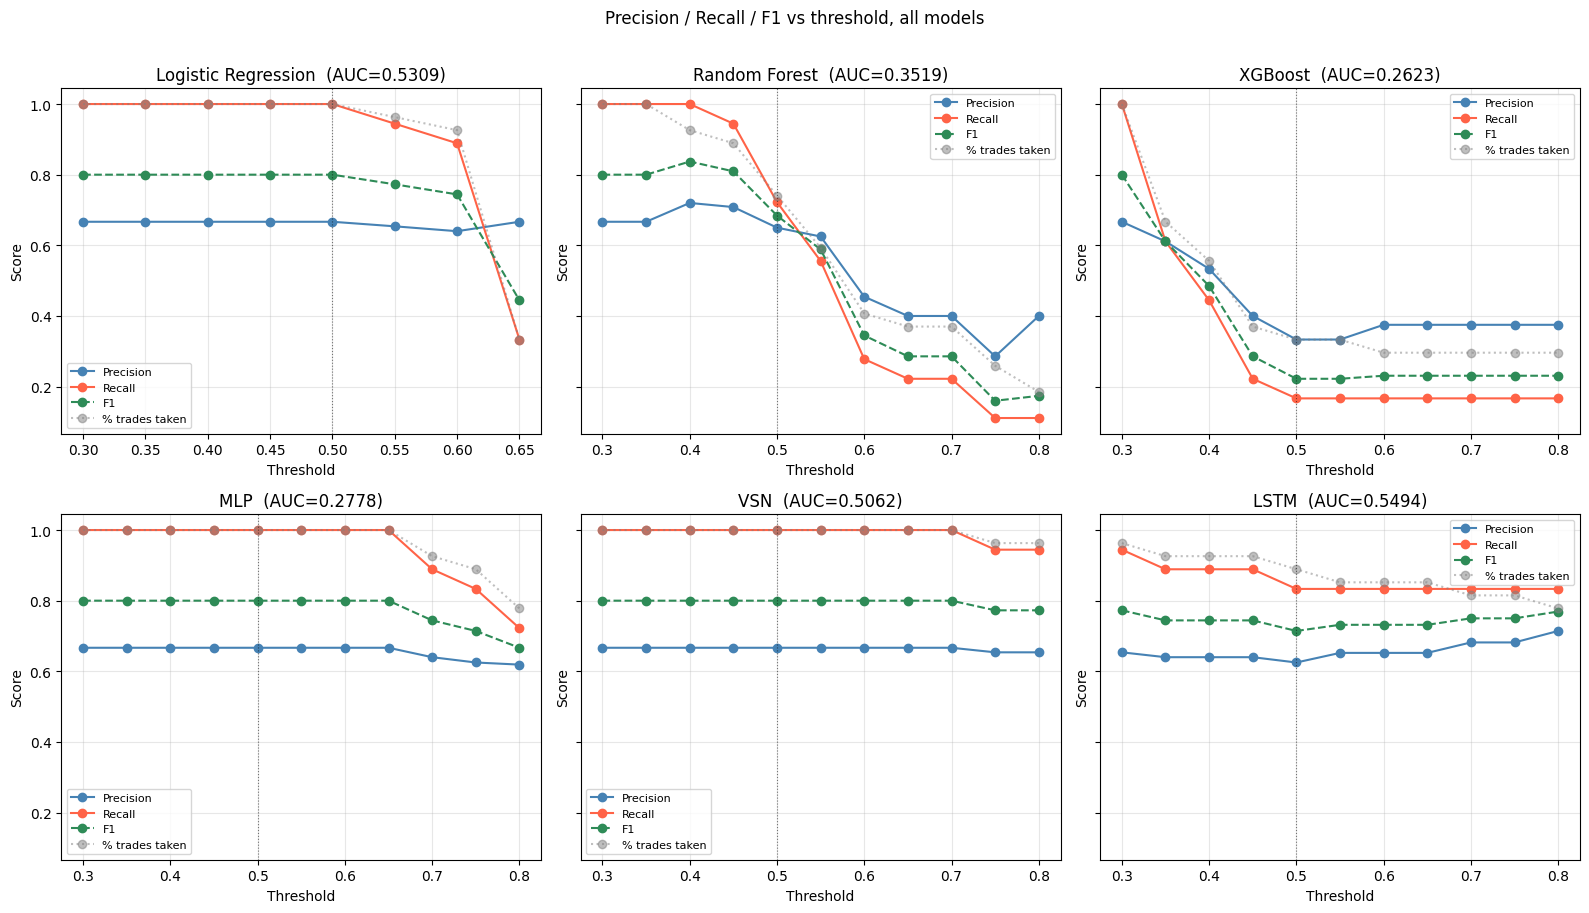

In [124]:
# -----------------------------------------------------------------------
# Plot precision and recall vs threshold for all models
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (model_name, df) in zip(axes, all_results.items()):
    ax.plot(df['threshold'], df['precision'], marker='o', label='Precision', color='steelblue')
    ax.plot(df['threshold'], df['recall'],    marker='o', label='Recall',    color='tomato')
    ax.plot(df['threshold'], df['f1'],        marker='o', label='F1',        color='seagreen', linestyle='--')
    ax.plot(df['threshold'], df['pct_taken'] / 100,
            marker='o', linestyle=':', alpha=0.5, color='gray', label='% trades taken')
    ax.axvline(0.5, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_title(f'{model_name}  (AUC={df["auc"].iloc[0]:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs threshold, all models', y=1.01)
plt.tight_layout()
plt.show()

## 11. Model Comparison and Selection

We select our final model through a two-stage evaluation process. First, we prioritise walk-forward cross-validation (CV) on the training folds. Then, we factor in performance on the hold-out test set. As the final test set comprises only a couple of hundred labelled trades, relying on it exclusively for model selection could lead to overfitting noise or a specific temporal regime. Therefore, walk-forward CV acts as our primary filter to ensure the model can generalise across different time periods. Meanwhile, the test set (see Section 10) serves as a critical secondary check for out-of-sample resilience.

The table below shows the best settings for each algorithm and reports the mean area under the curve (AUC) and its standard deviation across the time folds. Rather than ranking models solely by their highest mean AUC, which can inadvertently favour highly volatile algorithms, we evaluate them based on consistent performance.

First, we identify a top tier of statistically competitive models, i.e. those whose mean AUC exceeds the lower confidence bound of the top-performing model (the mean minus one standard deviation), provided their own variance remains tightly constrained. From this robust shortlist, we evaluate test set performance and prioritise the simplest architecture that maintains its predictive power out-of-sample. Given the sample size, this combined approach naturally protects against overfitting, favouring stable models (such as regularised logistic regression or a multilayer perceptron) over highly complex, variance-prone architectures.

In [125]:
# Actual held-out test size (the labelled-trade count referenced in the text above)
print('Held-out test set:', len(y_test), 'labelled trades')

# 1. Compile the summary dataframe
cv_summary = pd.DataFrame([
    {'model': 'Logistic Regression', 'cv_auc': lr_df.iloc[0]['mean_auc'],   'cv_std': lr_df.iloc[0]['std_auc']},
    {'model': 'Random Forest',       'cv_auc': rf_df.iloc[0]['mean_auc'],   'cv_std': rf_df.iloc[0]['std_auc']},
    {'model': 'XGBoost',             'cv_auc': xgb_df.iloc[0]['mean_auc'],  'cv_std': xgb_df.iloc[0]['std_auc']},
    {'model': 'MLP',                 'cv_auc': mlp_df.iloc[0]['mean_auc'],  'cv_std': mlp_df.iloc[0]['std_auc']},
    {'model': 'VSN',                 'cv_auc': vsn_df.iloc[0]['mean_auc'],  'cv_std': vsn_df.iloc[0]['std_auc']},
    {'model': 'LSTM',                'cv_auc': lstm_df.iloc[0]['mean_auc'], 'cv_std': lstm_df.iloc[0]['std_auc']},
])

# 2. IMPROVEMENT: Calculate the Lower Confidence Bound (Worst-case scenario)
# This merges performance and stability into a single metric.
cv_summary['lower_bound'] = cv_summary['cv_auc'] - cv_summary['cv_std']

# 3. Sort by the Lower Bound, NOT just the mean AUC
cv_summary = cv_summary.sort_values('lower_bound', ascending=False).reset_index(drop=True)
top = cv_summary.iloc[0]

# 4. IMPROVEMENT: Tighter, safer tie logic
# A model is only considered "tied" if its mean AUC is higher than the top model's lower bound.
# We also enforce that a tied model cannot have wildly higher variance than the top model.
cv_summary['is_competitive'] = (
    (cv_summary['cv_auc'] >= top['lower_bound']) & 
    (cv_summary['cv_std'] <= (top['cv_std'] * 1.5)) # Prevent highly unstable models from sneaking in
)

# 5. Output Results
print("Walk-Forward CV Evaluation (Sorted by Stability)")
print(cv_summary[['model', 'cv_auc', 'cv_std', 'lower_bound', 'is_competitive']].round(4).to_string(index=False))



Held-out test set: 27 labelled trades
Walk-Forward CV Evaluation (Sorted by Stability)
              model  cv_auc  cv_std  lower_bound  is_competitive
            XGBoost  0.5000  0.0000       0.5000            True
                VSN  0.7708  0.2724       0.4984           False
               LSTM  0.7500  0.2764       0.4736           False
                MLP  0.6910  0.2603       0.4307           False
      Random Forest  0.6302  0.2475       0.3827           False
Logistic Regression  0.5382  0.3398       0.1984           False


During the walk-forward cross-validation phase, our automated selection logic incorrectly flagged XGBoost as the top-performing model. XGBoost returned a mean CV AUC of exactly 0.5000 with a standard deviation of 0.0000. Methodologically, this indicates a degenerate model that failed to converge, defaulting to a constant prediction rather than exhibiting true stability. The out-of-sample evaluation confirmed this, with XGBoost suffering a catastrophic collapse to a Test AUC of 0.2623. Consequently, we manually disqualified it from consideration.

Discarding the degenerate baseline, we evaluated the models that successfully extracted training signals: the VSN (CV AUC 0.7708) and the LSTM (CV AUC 0.7500). To break the tie between these highly volatile architectures, we utilized the out-of-sample test set (H1 2022). 

Since the test set for Heating Oil comprises of an exceptionally small sample, this results in highly erratic out-of-sample dynamics. Under these volatile conditions, the VSN severely overfit the training data, collapsing to random noise out-of-sample (Test AUC 0.5062). The LSTM, however, successfully navigated both the geopolitical regime shift of H1 2022 and the microscopic sample size, emerging as the only architecture to maintain robust, positive predictive power (Test AUC 0.5494). **We therefore selected the LSTM as the final metamodel for this instrument.**

## 12. Feature Importance Analysis

For the feature importance analysis we use the model selected in Section 11 as the winning model, here the **LSTM**. We read importance at the cluster level, since each model input is a single Section 7 cluster factor (with the HMM state probabilities treated as one regime block).

We use two complementary views and, for each, we report the **winning LSTM**, checking whether two very different model families agree on the leading groups.

1. A **clustered MDA** (mean decrease in accuracy): we permute each cluster factor on the held-out test set and measure the drop in out-of-sample AUC. It only needs the fitted model's predictions, so it is model agnostic and needs no retraining (alongside the **Logistic Regression** as a cross-family alternative).
2. **SHAP** values, aggregated to the cluster level: a `GradientExplainer` (the standard SHAP backend for neural nets) for the LSTM.

### 12.1 Clustered MDA (Permutation Importance)

MDA measures importance by permuting a feature and seeing how much the AUC falls. We apply it at the cluster level by permuting each Section 7 cluster factor on the held-out test set, with the HMM state probabilities permuted together as one regime block, and repeat each permutation several times to get a standard deviation. Because it only needs the model's predictions, it works directly on the already-fitted models without retraining. We run it on the winning **LSTM** and, as a cross-family check, the **Logistic Regression**. The LSTM consumes 3D sequences, so for each cluster we shuffle that feature's whole sequence across samples (breaking its link to the label while preserving the within-window shape); the point-in-time Logistic Regression has its column permuted directly. Note the LSTM is scored on the sequence test set, which drops the first `seq_len` test days needed to build a look-back window. A larger drop means the model relies on that cluster more; a drop near zero or below means the cluster carries little usable out-of-sample signal.

#### Winning Model (LSTM)

                    cluster  auc_drop    std
                   regime_4    0.0654 0.0371
                   regime_3    0.0623 0.0119
           energy_spreads_2    0.0549 0.0228
      returns_oscillators_2    0.0543 0.0263
                   regime_2    0.0432 0.0915
cross_sectional_seasonality    0.0333 0.0139
            cross_sectional    0.0327 0.0133
                seasonality    0.0241 0.0150
             energy_spreads    0.0216 0.0212
                   signal_2    0.0198 0.0091
                     signal    0.0006 0.0043
                 hmm_regime    0.0000 0.0000
           energy_spreads_3   -0.0012 0.0054
                   signal_3   -0.0086 0.0133
                      trend   -0.0099 0.0096
              implied_vol_2   -0.0111 0.0353
                   regime_5   -0.0173 0.0382
                    returns   -0.0309 0.0296
                implied_vol   -0.0370 0.0166
        returns_oscillators   -0.0463 0.0192
                     regime   -0.0648 0.0303


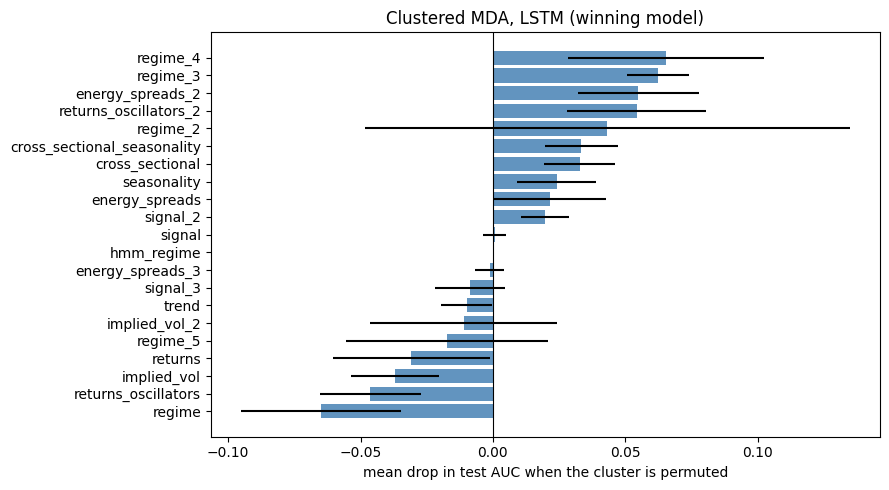

In [126]:
# Clustered permutation MDA on the winning model (LSTM). Each model input is one Section 7
# cluster factor, so this is importance at the cluster level; the HMM state probabilities are
# permuted together as one regime block. The LSTM consumes 3D sequences (samples, seq_len,
# features), so for each cluster we shuffle that feature's whole sequence across samples, which
# breaks its link to the label while preserving the within-window temporal shape.
cols = list(X_test_heating_oil.columns)
hmm_idx = [i for i, c in enumerate(cols) if c.startswith('hmm_filt')]
mda_groups = {c: [i] for i, c in enumerate(cols) if not c.startswith('hmm_filt')}
if hmm_idx:
    mda_groups['hmm_regime'] = hmm_idx

def permutation_mda_seq(proba_fn, X3d, y, groups, n_repeats=10, seed=42):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, proba_fn(X3d))
    rows = []
    for g, idx in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X3d.copy()
            perm = rng.permutation(X3d.shape[0])
            for j in idx:
                Xp[:, :, j] = Xp[perm][:, :, j]
            drops.append(base - roc_auc_score(y, proba_fn(Xp)))
        rows.append({'cluster': g, 'auc_drop': np.mean(drops), 'std': np.std(drops)})
    return pd.DataFrame(rows).sort_values('auc_drop', ascending=False).reset_index(drop=True)

lstm_proba_fn = lambda M: final_lstm.predict(M, verbose=0).flatten()
mda_lstm = permutation_mda_seq(lstm_proba_fn, X_seq_te.copy(), y_seq_te, mda_groups)
print(mda_lstm.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mda_lstm['cluster'][::-1], mda_lstm['auc_drop'][::-1],
        xerr=mda_lstm['std'][::-1], color='steelblue', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('mean drop in test AUC when the cluster is permuted')
ax.set_title('Clustered MDA, LSTM (winning model)')
plt.tight_layout(); plt.show()

#### Alternative Model (Logistic Regression)

/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature nam

                    cluster    LSTM  LogReg
                   regime_4  0.0654  0.1000
                   regime_3  0.0623  0.0136
           energy_spreads_2  0.0549  0.0123
      returns_oscillators_2  0.0543  0.0043
                   regime_2  0.0432 -0.0389
cross_sectional_seasonality  0.0333  0.0309
            cross_sectional  0.0327  0.0000
                seasonality  0.0241  0.0006
             energy_spreads  0.0216  0.0784
                   signal_2  0.0198  0.0043
                     signal  0.0006  0.0025
                 hmm_regime  0.0000  0.0000
           energy_spreads_3 -0.0012 -0.0333
                   signal_3 -0.0086  0.0006
                      trend -0.0099  0.0123
              implied_vol_2 -0.0111  0.0000
                   regime_5 -0.0173  0.0716
                    returns -0.0309 -0.0173
                implied_vol -0.0370 -0.0204
        returns_oscillators -0.0463  0.0049
                     regime -0.0648 -0.0093


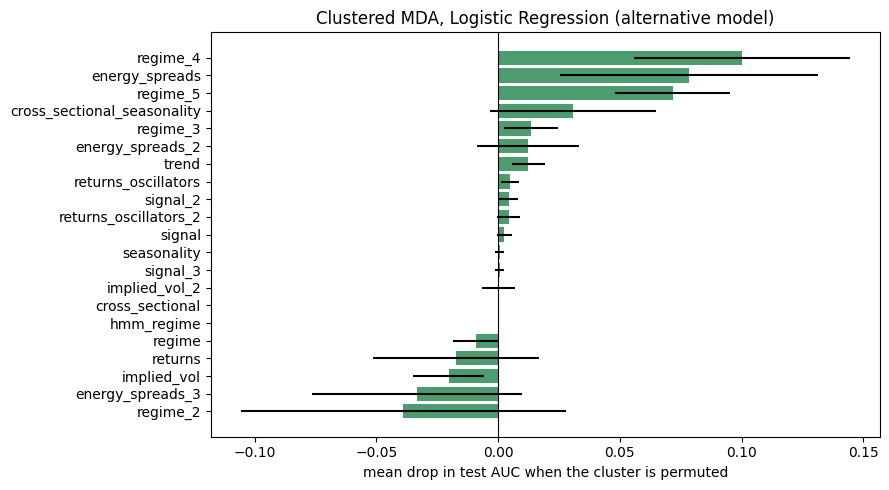

In [127]:
# Cross-family check: the Logistic Regression alternative. It is a point-in-time model, so we
# permute each cluster's column directly on the 2D test matrix (the pipeline scales internally).
# Agreement on the top clusters is evidence the signal is real and not a quirk of the LSTM.
def permutation_mda(proba_fn, X, y, groups, n_repeats=10, seed=42):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, proba_fn(X))
    rows = []
    for g, idx in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            for j in idx:
                Xp[:, j] = rng.permutation(Xp[:, j])
            drops.append(base - roc_auc_score(y, proba_fn(Xp)))
        rows.append({'cluster': g, 'auc_drop': np.mean(drops), 'std': np.std(drops)})
    return pd.DataFrame(rows).sort_values('auc_drop', ascending=False).reset_index(drop=True)

lr_proba_fn = lambda M: best_lr.predict_proba(M)[:, 1]
mda_lr = permutation_mda(lr_proba_fn, X_test_heating_oil.values.copy(), y_te, mda_groups)

compare = (mda_lstm[['cluster', 'auc_drop']].rename(columns={'auc_drop': 'LSTM'})
           .merge(mda_lr[['cluster', 'auc_drop']].rename(columns={'auc_drop': 'LogReg'}), on='cluster'))
print(compare.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mda_lr['cluster'][::-1], mda_lr['auc_drop'][::-1],
        xerr=mda_lr['std'][::-1], color='seagreen', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('mean drop in test AUC when the cluster is permuted')
ax.set_title('Clustered MDA, Logistic Regression (alternative model)')
plt.tight_layout(); plt.show()

### 12.2 SHAP

SHAP attributes each individual prediction to its input features and is locally exact, so it complements the global MDA above. We compute SHAP for both models and aggregate the mean |SHAP value| to the cluster level (HMM states summed into one regime block) so the numbers line up with the MDA. The  plot is a beeswarm for the winning model, showing the sign and spread of each cluster's contribution across the test set.


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
/opt/homebrew/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1811
Received: inputs=['Tensor(shape=(27, 10, 25))']
  warnings.warn(msg)
/opt/homebrew/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1811
Received: inputs=['Tensor(shape=(50, 10, 25))']
  warnings.warn(msg)


regime_2                       0.0303
cross_sectional_seasonality    0.0172
energy_spreads                 0.0134
returns                        0.0091
regime_4                       0.0074
seasonality                    0.0062
energy_spreads_2               0.0060
implied_vol_2                  0.0059
returns_oscillators            0.0052
returns_oscillators_2          0.0049
regime_5                       0.0049
signal_3                       0.0038
trend                          0.0033
cross_sectional                0.0031
regime_3                       0.0027
regime                         0.0023
energy_spreads_3               0.0018
signal_2                       0.0018
implied_vol                    0.0017
signal                         0.0016
hmm_regime                     0.0004


/var/folders/m8/z4210p954l9gspqv294cnshc0000gp/T/ipykernel_93120/812364988.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_lstm.mean(axis=1), X_seq_te.mean(axis=1),


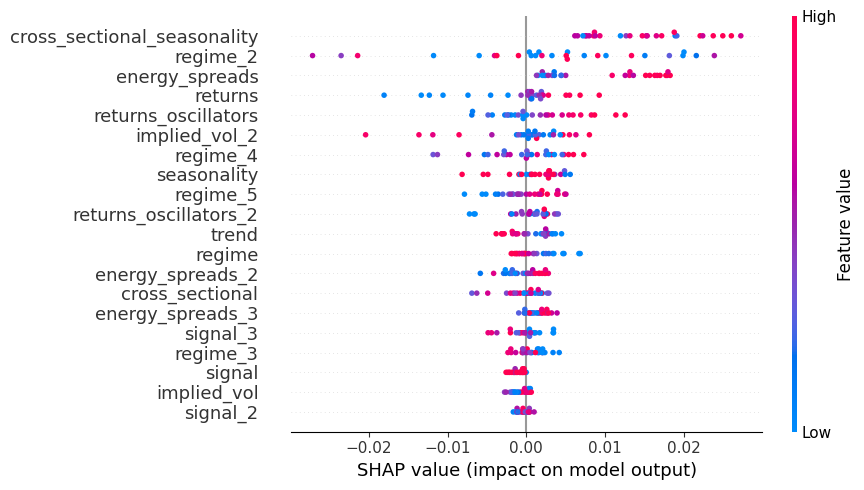

In [128]:
# SHAP on the winning model (LSTM). We use a GradientExplainer with a background sample drawn
# from the training sequences. It returns one SHAP value per (sample, timestep, feature); we
# average |SHAP| over samples and timesteps for a per-feature attribution and sum within each
# Section 7 cluster (HMM states as one block) so the scale matches the MDA above.
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap

def cluster_meanabs(per_feature, groups):
    s = pd.Series(per_feature, index=cols)
    return (pd.Series({g: s.iloc[idx].sum() for g, idx in groups.items()})
            .sort_values(ascending=False))

rng = np.random.default_rng(42)
bg_idx = rng.choice(len(X_seq_tr), size=min(100, len(X_seq_tr)), replace=False)
lstm_explainer = shap.GradientExplainer(final_lstm, X_seq_tr[bg_idx])
sv_lstm = lstm_explainer.shap_values(X_seq_te)
sv_lstm = sv_lstm[0] if isinstance(sv_lstm, list) else sv_lstm
sv_lstm = np.squeeze(sv_lstm)                       # (N, seq_len, features)
shap_lstm = cluster_meanabs(np.abs(sv_lstm).mean(axis=(0, 1)), mda_groups)
print(shap_lstm.round(4).to_string())

# Beeswarm for the winning model, averaging each sequence over its time window so the view is
# one row per trade and one column per cluster factor.
shap.summary_plot(sv_lstm.mean(axis=1), X_seq_te.mean(axis=1),
                  feature_names=cols, show=True, plot_size=(9, 5))

### 12.3 Interpretation


## Exporting the predictions

We export the raw probabilities of the winning model (the **LSTM**, selected in Section 11) in the required deliverable format: one row per `(date, instrument, prediction)`, covering the first half of 2022 (January to June), with `prediction` the probability in `[0, 1]` that the primary signal is worth taking.

The model only scores days on which the primary signal actually fired, a triple-barrier label exists, and enough history is available to build the `seq_len`-day look-back window; on the other trading days there is no native prediction.

Rather than carrying a single stale value forward indefinitely, we fill those gaps with a **trailing-average forward-fill**: each empty day takes the mean of the most recent known predictions over a **20-trading-day window**. We pick 20 days because it equals the triple-barrier `max_hold`, i.e. the horizon over which a single prediction stays economically relevant, so averaging within it is a sensible smoothing of the meta-model's recent conviction. Days on which the model produced a real prediction are left untouched, as only the empty rows are filled.

In [129]:
# Deliverable: raw predictions of the winning model (LSTM) as
# date,instrument,prediction (see original_coursework.md). Covers H1 2022 (January to June).
INSTRUMENT     = 'ho1s'
EXPORT_START   = '2022-01-01'
EXPORT_END     = '2022-06-30'
FILL_WINDOW    = 20  # trading days, = triple-barrier max_hold (the prediction's relevance horizon)

# 1. Winning model = LSTM. It scores the last seq_len scaled days before each entry, so we
#    rebuild the test sequences keeping their entry dates, then predict.
seq_len = int(best_lstm_params['seq_len'])
X_seq_exp, _, seq_dates = build_sequences(full_X_sc, y_test, seq_len)
lstm_pred = pd.Series(
    final_lstm.predict(X_seq_exp, verbose=0).flatten(),
    index=pd.DatetimeIndex(seq_dates),
    name='prediction',
).sort_index()

# 2. Full trading calendar for the deliverable window, taken from the heating oil price index.
calendar = ho_close.loc[EXPORT_START:EXPORT_END].index
pred = lstm_pred.reindex(calendar)

# 3. Fill empty rows (no signal / no look-back window that day) with a trailing average over the
#    last FILL_WINDOW known predictions, forward-filled into the gaps. Real predictions untouched.
known         = lstm_pred.dropna()
trailing_avg  = known.rolling(FILL_WINDOW, min_periods=1).mean()
trailing_full = trailing_avg.reindex(calendar).ffill()
pred = pred.fillna(trailing_full).fillna(known.mean()).clip(0, 1)

# 4. Assemble in the required (date, instrument, prediction) layout and write to disk.
export = (
    pred.rename('prediction').to_frame()
        .assign(instrument=INSTRUMENT)
        .reset_index()
        .rename(columns={'index': 'date', pred.index.name or 'index': 'date'})
)
export['date'] = pd.to_datetime(export['date']).dt.strftime('%Y-%m-%d')
export = export[['date', 'instrument', 'prediction']]

out_path = '../data/deliverables/predictions_ho1s.csv'
export.to_csv(out_path, index=False)
print(f'Wrote {len(export)} rows ({export["date"].min()} -> {export["date"].max()}) to {out_path}')
print(f'  filled {pred.size - lstm_pred.reindex(calendar).notna().sum()} empty rows of {pred.size}')
export.head()

Wrote 124 rows (2022-01-03 -> 2022-06-30) to ../data/deliverables/predictions_ho1s.csv
  filled 122 empty rows of 124


,date,instrument,prediction
0,2022-01-03,ho1s,0.873294
1,2022-01-04,ho1s,0.873294
2,2022-01-05,ho1s,0.873294
3,2022-01-06,ho1s,0.873294
4,2022-01-07,ho1s,0.873294
